# 02. **`Geometry-conditioned neural operator`**, V2

**Purpose:** test whether a geometry and flow aligned local refinement mechanism improves airfoil flow prediction over a faithfully reproduced Deep Flow Prediction baseline.

The model combines a multiscale convolutional encoder, a low-resolution Fourier backbone, a decoder, and iterative learned local feature differences. Sampling directions come from freestream flow and raster surface normals. Learned weights combine valid neighboring features. The prediction remains supervised by the CFD targets.

**Status:** implementation and CPU synthetic execution can be checked without the CFD archive. This notebook does not contain completed full-budget CFD results, a demonstrated superiority result, or a verified novelty claim. It provides the experiments needed to assess those claims.

| Profile | Models and role | Budget per model/seed | Official test |
|---|---|---:|---|
| `smoke` | Four small architectures, synthetic software check | 2 steps, 1 seed | Never |
| `screen` | Original DFP, modern U-Net, FNO, proposed model | 2,000 steps, 1 seed | Never |
| `benchmark` | Four models plus larger DFP and proposed variants | 10,000 steps, 3 seeds | After all planned training |
| `ablations` | Proposed model and nine controlled changes | 10,000 steps, 3 seeds | Never, validation study |

Run notebook 01 first. Start with `screen`; complete validation experiments and make architecture decisions before `benchmark`. The six-model benchmark contains 18 runs and 180,000 optimizer steps. A checkpointed GPU run is required for practical completion. Equal optimizer steps do not mean equal compute; actual timings and parameter counts are recorded.

**Purpose of the code.** Check the runtime and use the same prepared-data directory as notebook 01.

In [ ]:
import os
import sys
from pathlib import Path
import importlib.util

if sys.version_info < (3, 12):
    raise RuntimeError('Use Python 3.12 or newer. This notebook was checked on Python 3.12.')
requirements = ['numpy', 'scipy', 'pandas', 'matplotlib']
missing = [name for name in requirements if importlib.util.find_spec(name) is None]
if missing:
    raise ImportError('Install missing packages in this kernel: %pip install ' + ' '.join(missing))
IN_COLAB = 'google.colab' in sys.modules or bool(os.environ.get('COLAB_RELEASE_TAG'))
if IN_COLAB and not os.environ.get('AIRFOIL_PROJECT_ROOT'):
    from google.colab import drive
    drive.mount('/content/drive')
DEFAULT_BASE = (Path('/content/drive/MyDrive/Colab Notebooks/Deep-Flow-Prediction')
                if IN_COLAB else Path.cwd())
PROJECT_ROOT = Path(os.environ.get('AIRFOIL_PROJECT_ROOT', str(DEFAULT_BASE/'rans_airfoil_project'/'publication_v2')))
SMOKE = os.environ.get('AIRFOIL_MODE', 'real') == 'smoke'
if SMOKE:
    PROJECT_ROOT = Path(os.environ.get('AIRFOIL_SMOKE_ROOT', '/tmp/airfoil_publication_v2_smoke'))
PREPARED_ROOT = PROJECT_ROOT/'prepared'
print('Project:', PROJECT_ROOT)
print('Mode:', 'SYNTHETIC SOFTWARE CHECK' if SMOKE else 'ORIGINAL CFD DATA')

if importlib.util.find_spec('torch') is None:
    raise ImportError('Install a PyTorch build appropriate for your CPU/CUDA runtime: https://pytorch.org/get-started/locally/')

Mounted at /content/drive
Project: /content/drive/MyDrive/Colab Notebooks/Deep-Flow-Prediction/rans_airfoil_project/publication_v2
Mode: ORIGINAL CFD DATA


**Purpose of the code.** Choose the experiment profile, study identity, and optional validation studies.

In [ ]:
PROFILE = 'smoke' if SMOKE else os.environ.get('AIRFOIL_PROFILE', 'screen')
PROTOCOL = 'official_random'
SPLIT_SEED = 31415
STUDY_NAME = os.environ.get('AIRFOIL_STUDY_NAME', 'study_01')
STUDY_ROOT = PROJECT_ROOT/'runs'/STUDY_NAME/PROFILE
SELECTED_MODELS = None   # None executes the entire profile; otherwise use a list of model names.
SEEDS = None             # Defaults: [42] for screening, [42,137,2026] for full experiments.
RUN_TRAINING = True
RUN_ABLATIONS = False
RUN_LEARNING_CURVES = False
RUN_GENERALIZATION = False
assert PROFILE in ['smoke','screen','benchmark','ablations']
print('Profile:', PROFILE, '| study:', STUDY_ROOT)

## Data conventions and target-compatible training

Every architecture receives freestream magnitude and direction. The historical DFP input is exactly the normalized pair of freestream fields and the mask. New geometric features are deterministic functions of those same inputs.

The primary objective is the authors' all-pixel L1 loss in the original normalized target representation, applied to all models. The primary benchmark has no added physics losses. Optional ablations add supervised near-surface or wake errors, spatial derivative matching, or divergence matching to the sampled CFD target. Every added term is zero when the prediction equals the target.

There is no laminar momentum residual applied to RANS targets, zero-divergence penalty on interpolated labels, zero-velocity fluid-band penalty, or imposed freestream value on crop edges. The data do not provide the complete turbulence closure or true wall mesh needed to justify those constraints.

**Purpose of the code.** Load the V2 data and preserve the same normalization, coordinates, split identities and training-only statistics. Implementation block 1.

In [ ]:
from __future__ import annotations

import copy
import hashlib
import json
import math
import os
import random
import re
import shutil
import tarfile
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.ndimage import distance_transform_edt, binary_erosion, binary_dilation

SCHEMA_VERSION = 'dfp-publication-v2.0'
ORIGINAL_COMMIT = '8a5efa4'
TARGET_SCALES = np.array([2.04, 2.37, 4.65], dtype=np.float32)  # u, v, kinematic p
INPUT_SCALES = np.array([100.0, 38.12], dtype=np.float32)


def json_hash(value):
    return hashlib.sha256(json.dumps(value, sort_keys=True, allow_nan=False).encode()).hexdigest()


def sha256_file(path):
    digest = hashlib.sha256()
    with open(path, 'rb') as handle:
        for block in iter(lambda: handle.read(1024 * 1024), b''):
            digest.update(block)
    return digest.hexdigest()


def write_json(path, value):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    temporary = path.with_suffix(path.suffix + '.tmp')
    temporary.write_text(json.dumps(value, indent=2, sort_keys=True, allow_nan=False))
    temporary.replace(path)


def read_json(path):
    return json.loads(Path(path).read_text())


def original_coordinates(size=128):
    # The generator samples endpoints with i/res, not i/(res-1).
    x = -0.5 + 2.0 * np.arange(size, dtype=np.float64) / size
    y = -1.0 + 2.0 * np.arange(size, dtype=np.float64) / size
    xx, yy = np.meshgrid(x, y, indexing='xy')
    return xx.astype(np.float32), yy.astype(np.float32), 2.0 / size


def group_from_filename(path):
    # Original files end in two signed integer velocity components.
    match = re.fullmatch(r'(.+)_(-?\d+)_(-?\d+)', Path(path).stem)
    if match is None:
        raise ValueError(f'Cannot infer airfoil identity from {Path(path).name}. Supply original filenames.')
    return match.group(1).casefold()


def extract_archive_safely(archive, destination):
    archive, destination = Path(archive), Path(destination)
    digest = sha256_file(archive)
    marker = destination / 'archive_receipt.json'
    if marker.exists():
        if read_json(marker)['archive_sha256'] != digest:
            raise ValueError('Extraction directory belongs to a different archive. Use a new directory.')
        return destination
    if destination.exists() and any(destination.iterdir()):
        raise ValueError('Use an empty extraction directory or an existing verified extraction.')
    destination.mkdir(parents=True, exist_ok=True)
    with tarfile.open(archive, 'r:*') as stream:
        members = stream.getmembers()
        root = destination.resolve()
        for member in members:
            resolved = (root / member.name).resolve()
            if not resolved.is_relative_to(root) or member.issym() or member.islnk():
                raise ValueError(f'Unsafe archive member: {member.name}')
            if not (member.isfile() or member.isdir()):
                raise ValueError(f'Unsupported archive member: {member.name}')
        stream.extractall(root, members=members, filter='data')
    write_json(marker, {'archive_sha256': digest, 'archive_name': archive.name})
    return destination


def discover_original_files(raw_root):
    train, test = [], []
    for path in sorted(Path(raw_root).rglob('*.npz')):
        # Exact path components prevent 'training_project/test' being classified twice.
        parts = [p.casefold() for p in path.relative_to(raw_root).parts[:-1]]
        if 'train' in parts and 'test' in parts:
            raise ValueError(f'Ambiguous split: {path}')
        if 'train' in parts:
            train.append(path)
        elif 'test' in parts:
            test.append(path)
    if not train or not test:
        raise FileNotFoundError('Expected original train/*.npz and test/*.npz under RAW_ROOT.')
    return train, test


def read_original_sample(path, verified_nu=None, chord=1.0):
    with np.load(path, allow_pickle=False) as archive:
        if 'a' not in archive.files:
            raise ValueError(f'{path}: expected original NPZ key a.')
        raw = np.asarray(archive['a'], dtype=np.float64)
    if raw.shape != (6, 128, 128) or not np.isfinite(raw).all():
        raise ValueError(f'{path}: expected finite [6,128,128] original data.')
    # Transpose SPATIAL axes only. Velocity channel meanings remain unchanged.
    a = raw.transpose(0, 2, 1).copy()
    solid = a[2] > 0.5
    if not np.isin(a[2], [0, 1]).all() or solid.sum() == 0 or (~solid).sum() == 0:
        raise ValueError(f'{path}: invalid solid mask.')
    fluid = ~solid
    fs = np.array([np.median(a[0][fluid]), np.median(a[1][fluid])])
    U = float(np.linalg.norm(fs))
    if U <= 0 or not all(np.allclose(a[k], fs[k] * fluid, atol=1e-5) for k in [0, 1]):
        raise ValueError(f'{path}: inconsistent freestream channels.')
    if not (9.9 <= U <= 100.1):
        raise ValueError('Raw speed outside the original 10-100 range. Do not pass normalized arrays.')
    # EXACT legacy transformation: mean over ALL pixels, then zero solid pressure.
    p = (a[3] - a[3].mean()) * fluid
    star = np.stack([a[4] / U, a[5] / U, p / (U * U)])
    legacy = (star / TARGET_SCALES[:, None, None]).astype(np.float32)
    xx, yy, spacing = original_coordinates(128)
    sdf = (distance_transform_edt(fluid, sampling=spacing)
           - distance_transform_edt(solid, sampling=spacing)).astype(np.float32)
    input_hash = hashlib.sha256(np.ascontiguousarray(raw[:3]).tobytes()).hexdigest()
    mask_hash = hashlib.sha256(np.ascontiguousarray(solid).tobytes()).hexdigest()
    row = {
        'sample_id': Path(path).stem,
        'airfoil_id': group_from_filename(path),
        'source_path': str(Path(path).resolve()),
        'source_sha256': sha256_file(path),
        'input_sha256': input_hash,
        'mask_sha256': mask_hash,
        'u_inf': float(fs[0]), 'v_inf': float(fs[1]), 'speed': U,
        'flow_angle_deg': float(np.degrees(np.arctan2(fs[1], fs[0]))),
        're_paper_estimate': U * 50_000.0,
        're_physical': None if verified_nu is None else U * chord / verified_nu,
    }
    return legacy, solid.astype(np.uint8), sdf, row

**Purpose of the code.** Load the V2 data and preserve the same normalization, coordinates, split identities and training-only statistics. Implementation block 2.

In [ ]:
def prepare_original_dataset(raw_root, output_root, verified_nu=None,
                             viscosity_evidence=None, chord=1.0, synthetic=False):
    output_root = Path(output_root)
    if verified_nu is not None and (verified_nu <= 0 or not viscosity_evidence):
        raise ValueError('Verified positive viscosity requires a provenance note.')
    if output_root.exists() and any(output_root.iterdir()):
        raise FileExistsError('Prepared directory already exists. Use a new versioned directory.')
    train, test = discover_original_files(raw_root)
    settings = {
        'schema': SCHEMA_VERSION, 'source_layout': 'CXY', 'prepared_layout': 'CYX',
        'size': 128, 'dx': 2 / 128, 'dy': 2 / 128,
        'x_origin': -0.5, 'y_origin': -1.0, 'chord': chord,
        'pressure_units': 'kinematic pressure; m^2/s^2',
        'target_order': ['u', 'v', 'p'],
        'normalization': 'legacy_all_pixel_pressure_gauge_then_fixed_maxima',
        'target_scales': TARGET_SCALES.tolist(), 'input_scales': INPUT_SCALES.tolist(),
        'verified_nu': verified_nu, 'viscosity_evidence': viscosity_evidence,
        're_status': 'paper mapping is estimated; physical Re null without verified viscosity',
        'synthetic': bool(synthetic), 'original_commit': ORIGINAL_COMMIT,
    }
    manifest = []
    try:
        for split, files in [('train', train), ('test', test)]:
            folder = output_root / split
            folder.mkdir(parents=True)
            target = np.lib.format.open_memmap(folder / 'target_legacy.npy', mode='w+',
                dtype=np.float32, shape=(len(files), 3, 128, 128))
            masks = np.lib.format.open_memmap(folder / 'solid.npy', mode='w+',
                dtype=np.uint8, shape=(len(files), 128, 128))
            sdfs = np.lib.format.open_memmap(folder / 'sdf.npy', mode='w+',
                dtype=np.float32, shape=(len(files), 128, 128))
            for i, path in enumerate(files):
                target[i], masks[i], sdfs[i], row = read_original_sample(path, verified_nu, chord)
                row.update(split=split, index=i)
                manifest.append(row)
                if (i + 1) % 500 == 0:
                    print(f'{split}: {i + 1}/{len(files)}')
            target.flush(); masks.flush(); sdfs.flush()
            del target, masks, sdfs
        table = pd.DataFrame(manifest)
        if table['sample_id'].duplicated().any() or table['input_sha256'].duplicated().any():
            raise ValueError('Duplicate sample identity or identical inputs detected. Audit before training.')
        tr, te = table[table.split == 'train'], table[table.split == 'test']
        overlap = sorted(set(tr.airfoil_id) & set(te.airfoil_id))
        if overlap:
            raise ValueError(f'Train/test airfoil identity overlap: {overlap[:8]}')
        raster_overlap = sorted(set(tr.mask_sha256) & set(te.mask_sha256))
        table.to_csv(output_root / 'manifest.csv', index=False)
        hashes = {str(p.relative_to(output_root)): sha256_file(p)
                  for p in sorted(output_root.rglob('*.npy'))}
        identity = json_hash({'settings': settings, 'manifest': manifest, 'arrays': hashes})
        metadata = {'settings': settings, 'dataset_id': identity, 'array_sha256': hashes,
                    'manifest_sha256': sha256_file(output_root / 'manifest.csv'),
                    'train_samples': len(train), 'test_samples': len(test),
                    'test_airfoils': int(te.airfoil_id.nunique()),
                    'raster_overlap_count': len(raster_overlap),
                    'raster_overlap_note': 'Report raster collisions; do not silently alter the official benchmark.'}
        write_json(output_root / 'metadata.json', metadata)
        return metadata
    except Exception:
        # Preserve partial files for diagnosis; metadata.json is the completion receipt.
        raise


def verify_prepared_dataset(root, full_hash_check=False):
    root = Path(root)
    meta = read_json(root / 'metadata.json')
    if meta['settings']['schema'] != SCHEMA_VERSION:
        raise ValueError('Prepared schema mismatch. Rerun preparation notebook V2.')
    if sha256_file(root / 'manifest.csv') != meta['manifest_sha256']:
        raise ValueError('Prepared manifest changed.')
    if full_hash_check:
        for name, digest in meta['array_sha256'].items():
            if sha256_file(root / name) != digest:
                raise ValueError(f'Prepared array changed: {name}')
    return meta


def create_split(root, protocol='official_random', seed=31415):
    meta = verify_prepared_dataset(root)
    table = pd.read_csv(Path(root) / 'manifest.csv')
    table = table[table.split == 'train'].reset_index(drop=True)
    rng = np.random.default_rng(seed)
    n_val = max(1, min(400, int(len(table) * 0.2)))
    if protocol == 'official_random':
        val = sorted(rng.permutation(len(table))[:n_val].tolist())
    elif protocol == 'geometry_validation':
        # Group on raster identity too: union airfoil IDs that have equal masks.
        parent = {x: x for x in table.airfoil_id.unique()}
        def find(x):
            while parent[x] != x:
                parent[x] = parent[parent[x]]; x = parent[x]
            return x
        for _, group in table.groupby('mask_sha256'):
            ids = group.airfoil_id.unique()
            for g in ids[1:]:
                parent[find(g)] = find(ids[0])
        components = table.airfoil_id.map(find)
        ordered = rng.permutation(sorted(components.unique()))
        val = []
        for g in ordered:
            val.extend(np.flatnonzero(components.to_numpy() == g).tolist())
            if len(val) >= n_val:
                break
        val = sorted(val)
    elif protocol in ['speed_extrapolation', 'angle_extrapolation']:
        values = table.speed.to_numpy() if protocol == 'speed_extrapolation' else np.abs(table.flow_angle_deg.to_numpy())
        threshold = 80.0 if protocol == 'speed_extrapolation' else 15.0
        val = np.flatnonzero(values > threshold).tolist()
    else:
        raise ValueError(protocol)
    train = sorted(set(range(len(table))) - set(val))
    if len(train) < 2 or not val:
        raise ValueError('Split too small for training and validation.')
    result = {'dataset_id': meta['dataset_id'], 'protocol': protocol, 'split_seed': seed,
              'train_indices': train, 'val_indices': val,
              'note': 'Fixed reconstructed split, not the unavailable authors original randomized sample list.'}
    result['split_id'] = json_hash(result)
    write_json(Path(root) / 'splits' / f'{protocol}_{seed}.json', result)
    return result

**Purpose of the code.** Load the V2 data and preserve the same normalization, coordinates, split identities and training-only statistics. Implementation block 3.

In [ ]:
def fit_condition_stats(root, split):
    table = pd.read_csv(Path(root) / 'manifest.csv')
    table = table[table.split == 'train'].reset_index(drop=True).iloc[split['train_indices']]
    values = np.stack([table.u_inf / table.speed, table.v_inf / table.speed,
                       np.log(table.speed / 10.0)], axis=1).astype(np.float64)
    return {'mean': values.mean(0).tolist(), 'std': np.maximum(values.std(0), 1e-6).tolist(),
            'split_id': split['split_id'], 'features': ['flow_cos', 'flow_sin', 'log_speed_over_10'],
            'target_statistics': 'Fixed original maxima; no fitted target statistics.'}


def make_synthetic_original_dataset(root, train_groups=6, test_groups=2):
    # Integration fixture only. These are NOT CFD solutions and cannot support results.
    root = Path(root)
    xx, yy, _ = original_coordinates()
    for split, groups, offset in [('train', train_groups, 0), ('test', test_groups, 100)]:
        (root / split).mkdir(parents=True, exist_ok=True)
        for g in range(groups):
            index = g + offset
            thickness = 0.04 + 0.003 * (index % 20)
            camber = (index % 7 - 3) * 0.004
            solid = ((xx - 0.5) / 0.5) ** 2 + ((yy - camber) / thickness) ** 2 < 1
            fluid = ~solid
            for k, angle in enumerate([-8.0, 6.0, 18.0]):
                U = 20.0 + 12 * k + (g % 3)
                theta = np.radians(angle)
                fsx, fsy = U * np.cos(theta), U * np.sin(theta)
                wake = np.exp(-((yy - camber - 0.15 * (xx - 1)) / 0.12) ** 2) * np.clip(xx - 0.8, 0, 1)
                p = -0.1 * U**2 * np.exp(-((xx - .4)**2 + yy**2) / .05) * fluid
                u = fsx * (1 - 0.25 * wake) * fluid
                v = (fsy + 0.1 * U * wake) * fluid
                a = np.stack([fsx * fluid, fsy * fluid, solid, p, u, v]).transpose(0, 2, 1)
                np.savez_compressed(root / split / f'synthetic{index:03d}_{int(fsx*100)}_{int(fsy*100)}.npz', a=a)
    return root

## Exact historical baseline

The following generator is copied from commit `8a5efa4`, which matches the published pretrained-network architecture. It retains the original layer names and tensor operations. A wrapper transposes spatial axes into the authors' convention and maps output channels back to `[u,v,p]`. It does not replace the original architecture with an approximate U-Net. The 7.736-million and 30.906-million parameter capacities are included.

Original attribution: N. Thuerey, K. Weissenow, H. Mehrotra, N. Mainali, L. Prantl, X. Hu, TUM. Apache License 2.0; the full license is included at the end of this notebook and in the bundle. The generator below is unchanged; its unused discriminator is omitted. The wrapper and research workflow are new.

**Purpose of the code.** Define the original TurbNetG generator with its attribution and original implementation.

In [ ]:
################
#
# Deep Flow Prediction - N. Thuerey, K. Weissenov, H. Mehrotra, N. Mainali, L. Prantl, X. Hu (TUM)
#
# CNN setup and data normalization
#
################

import torch
import torch.nn as nn
import torch.nn.functional as F

def weights_init(m):
    classname = m.__class__.__name__
    if classname.find('Conv') != -1:
        m.weight.data.normal_(0.0, 0.02)
    elif classname.find('BatchNorm') != -1:
        m.weight.data.normal_(1.0, 0.02)
        m.bias.data.fill_(0)

def blockUNet(in_c, out_c, name, transposed=False, bn=True, relu=True, size=4, pad=1, dropoutVal=0.):
    block = nn.Sequential()
    if relu:
        block.add_module('%s_relu' % name, nn.ReLU(inplace=True))
    else:
        block.add_module('%s_leakyrelu' % name, nn.LeakyReLU(0.2, inplace=True))
    if not transposed:
        block.add_module('%s_conv' % name, nn.Conv2d(in_c, out_c, kernel_size=size, stride=2, padding=pad, bias=True))
    else:
        block.add_module('%s_upsam' % name, nn.Upsample(scale_factor=2))
        block.add_module('%s_tconv' % name, nn.Conv2d(in_c, out_c, kernel_size=(size-1), stride=1, padding=pad, bias=True))
    if bn:
        block.add_module('%s_bn' % name, nn.BatchNorm2d(out_c))
    if dropoutVal>0.:
        block.add_module('%s_dropout' % name, nn.Dropout2d( dropoutVal, inplace=True))
    return block

# generator model
class TurbNetG(nn.Module):
    def __init__(self, channelExponent=6, drv=0.):
        super(TurbNetG, self).__init__()
        channels = int(2 ** channelExponent + 0.5)

        self.layer1 = nn.Sequential()
        self.layer1.add_module('layer1_conv', nn.Conv2d(3, channels, 4, 2, 1, bias=True))

        self.layer2 = blockUNet(channels  , channels*2, 'layer2', transposed=False, bn=True,  relu=False, dropoutVal=drv )
        self.layer2x= blockUNet(channels*2, channels*2, 'layer2x',transposed=False, bn=True,  relu=False, dropoutVal=drv )
        self.layer3 = blockUNet(channels*2, channels*4, 'layer3', transposed=False, bn=True,  relu=False, dropoutVal=drv )
        self.layer4 = blockUNet(channels*4, channels*8, 'layer4', transposed=False, bn=True,  relu=False, dropoutVal=drv , size=2,pad=0)
        self.layer5 = blockUNet(channels*8, channels*8, 'layer5', transposed=False, bn=True,  relu=False, dropoutVal=drv , size=2,pad=0)
        self.layer6 = blockUNet(channels*8, channels*8, 'layer6', transposed=False, bn=False, relu=False, dropoutVal=drv , size=2,pad=0)

        self.dlayer6 = blockUNet(channels*8, channels*8, 'dlayer6', transposed=True, bn=True, relu=True, dropoutVal=drv , size=2,pad=0)
        self.dlayer5 = blockUNet(channels*16,channels*8, 'dlayer5', transposed=True, bn=True, relu=True, dropoutVal=drv , size=2,pad=0)
        self.dlayer4 = blockUNet(channels*16,channels*4, 'dlayer4', transposed=True, bn=True, relu=True, dropoutVal=drv )
        self.dlayer3 = blockUNet(channels*8, channels*2, 'dlayer3', transposed=True, bn=True, relu=True, dropoutVal=drv )
        self.dlayer2x= blockUNet(channels*4, channels*2, 'dlayer2x',transposed=True, bn=True, relu=True, dropoutVal=drv )
        self.dlayer2 = blockUNet(channels*4, channels  , 'dlayer2', transposed=True, bn=True, relu=True, dropoutVal=drv )

        self.dlayer1 = nn.Sequential()
        self.dlayer1.add_module('dlayer1_relu', nn.ReLU(inplace=True))
        self.dlayer1.add_module('dlayer1_tconv', nn.ConvTranspose2d(channels*2, 3, 4, 2, 1, bias=True))

    def forward(self, x):
        out1 = self.layer1(x)
        out2 = self.layer2(out1)
        out2x= self.layer2x(out2)
        out3 = self.layer3(out2x)
        out4 = self.layer4(out3)
        out5 = self.layer5(out4)
        out6 = self.layer6(out5)
        dout6 = self.dlayer6(out6)
        dout6_out5 = torch.cat([dout6, out5], 1)
        dout5 = self.dlayer5(dout6_out5)
        dout5_out4 = torch.cat([dout5, out4], 1)
        dout4 = self.dlayer4(dout5_out4)
        dout4_out3 = torch.cat([dout4, out3], 1)
        dout3 = self.dlayer3(dout4_out3)
        dout3_out2x = torch.cat([dout3, out2x], 1)
        dout2x = self.dlayer2x(dout3_out2x)
        dout2x_out2 = torch.cat([dout2x, out2], 1)
        dout2 = self.dlayer2(dout2x_out2)
        dout2_out1 = torch.cat([dout2, out1], 1)
        dout1 = self.dlayer1(dout2_out1)
        return dout1

## Proposed mechanism and comparison architectures

At each refinement step, the model samples feature differences at radii of one and three raster pixels along positive/negative flow and surface-normal directions. Away from the surface it uses the direction perpendicular to flow. It rejects endpoint and intermediate bilinear supports that touch solid pixels or leave the crop. Learned normalized weights combine the remaining differences before a residual feature update.

This is a learned predictor, not a discretized RANS solver. The zero-initialized output correction starts from the multiscale backbone prediction. Gradients reach its output head first, then the internal refinement parameters as the head learns. Shared refinement weights allow the larger configuration to increase iteration depth without duplicating all local parameters.

The comparison includes a modern U-Net using the same derived features and a conventional Fourier model. The `no_local_refinement` ablation isolates the multiscale spectral backbone. All capacities are reported; they are not described as exactly parameter matched.

**Purpose of the code.** Define the dataset tensors, original baseline wrapper, comparison models, and proposed refinement mechanism. Implementation block 1.

In [ ]:
import torch
from torch import nn
from torch.nn import functional as F
from torch.utils.data import Dataset, DataLoader


class AirfoilDataset(Dataset):
    def __init__(self, root, storage_split, indices, condition_stats, options=None):
        self.root = Path(root)
        self.storage_split = storage_split
        self.indices = list(indices)
        self.stats = condition_stats
        self.options = {} if options is None else options
        self.meta = verify_prepared_dataset(root)
        self.rows = pd.read_csv(self.root / 'manifest.csv')
        self.rows = self.rows[self.rows.split == storage_split].reset_index(drop=True)
        self._open_arrays()
        self.xx, self.yy, self.spacing = original_coordinates()

    def _open_arrays(self):
        folder = self.root / self.storage_split
        self.targets = np.load(folder / 'target_legacy.npy', mmap_mode='r')
        self.solid = np.load(folder / 'solid.npy', mmap_mode='r')
        self.sdf = np.load(folder / 'sdf.npy', mmap_mode='r')

    def __getstate__(self):
        state = self.__dict__.copy()
        for name in ['targets', 'solid', 'sdf']:
            state.pop(name)
        return state

    def __setstate__(self, state):
        self.__dict__.update(state)
        self._open_arrays()

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, item):
        i = self.indices[item]
        row = self.rows.iloc[i]
        solid = np.asarray(self.solid[i], dtype=np.float32)
        fluid = 1 - solid
        sdf = np.array(self.sdf[i], copy=True)
        gy, gx = np.gradient(sdf, self.spacing, self.spacing)
        length = np.sqrt(gx**2 + gy**2 + 1e-12)
        nx, ny = gx / length, gy / length
        U = float(row.speed)
        direction = np.array([row.u_inf / U, row.v_inf / U], dtype=np.float32)
        raw_cond = np.array([*direction, np.log(U / 10.0)], dtype=np.float32)
        cond = (raw_cond - np.array(self.stats['mean'])) / np.array(self.stats['std'])
        fs = np.stack([np.full_like(solid, row.u_inf / 100.0),
                       np.full_like(solid, row.v_inf / 38.12)]) * fluid
        # Geometric trailing edge is max physical x, then project displacement onto flow.
        ys, xs = np.where(solid > 0.5)
        trailing = xs.max()
        te_x = float(self.xx[ys[xs == trailing], xs[xs == trailing]].mean())
        te_y = float(self.yy[ys[xs == trailing], xs[xs == trailing]].mean())
        rx, ry = self.xx - te_x, self.yy - te_y
        stream = rx * direction[0] + ry * direction[1]
        cross = -rx * direction[1] + ry * direction[0]
        near = ((sdf > 0) & (sdf <= 0.08)).astype(np.float32)
        wake = ((stream > 2 * self.spacing) & (np.abs(cross) < .08 + .15*np.maximum(stream, 0))).astype(np.float32) * fluid
        interior = binary_erosion(fluid > .5, structure=np.ones((3, 3)), border_value=0).astype(np.float32)
        model_sdf, model_nx, model_ny, model_near = sdf, nx, ny, near
        if not self.options.get('use_sdf', True):
            model_sdf = np.zeros_like(sdf)
            model_nx, model_ny, model_near = np.zeros_like(nx), np.zeros_like(ny), np.zeros_like(near)
        features = np.stack([solid, np.clip(model_sdf, -1, 1), model_nx, model_ny,
            self.xx - .5, self.yy, fs[0], fs[1], stream, cross, model_near, wake], axis=0)
        arrays = {'features': features, 'legacy_input': np.concatenate([fs, solid[None]], axis=0),
                  'target': np.array(self.targets[i], copy=True), 'fluid': fluid[None],
                  'interior': interior[None], 'near': near[None], 'wake': wake[None],
                  'normals': np.stack([model_nx, model_ny]), 'direction': direction,
                  'condition': cond.astype(np.float32)}
        batch = {k: torch.from_numpy(np.ascontiguousarray(v, dtype=np.float32)) for k, v in arrays.items()}
        batch.update(sample_id=str(row.sample_id), airfoil_id=str(row.airfoil_id),
                     speed=torch.tensor(U, dtype=torch.float32),
                     angle=torch.tensor(row.flow_angle_deg, dtype=torch.float32))
        return batch


class OriginalDeepFlow(nn.Module):
    def __init__(self, exponent=6, dropout=0.01):
        super().__init__()
        self.net = TurbNetG(channelExponent=exponent, drv=dropout)
        self.net.apply(weights_init)

    def forward(self, b):
        # Historical weights operate on CXY arrays; user-facing tensors are CYX.
        original = b['legacy_input'].transpose(-1, -2).contiguous()
        p_uv = self.net(original)
        result = p_uv[:, [1, 2, 0]].transpose(-1, -2).contiguous()
        return {'prediction': result, 'coarse': result}


class ResidualConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        groups = math.gcd(8, out_ch)
        self.body = nn.Sequential(nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.GroupNorm(groups, out_ch), nn.GELU(),
            nn.Conv2d(out_ch, out_ch, 3, padding=1), nn.GroupNorm(groups, out_ch))
        self.skip = nn.Identity() if in_ch == out_ch else nn.Conv2d(in_ch, out_ch, 1)

    def forward(self, x):
        return F.gelu(self.body(x) + self.skip(x))


class ScalarFiLM(nn.Module):
    def __init__(self, channels, enabled=True):
        super().__init__()
        self.enabled = enabled
        self.net = nn.Sequential(nn.Linear(3, 64), nn.GELU(), nn.Linear(64, 2*channels)) if enabled else None
        if enabled:
            nn.init.zeros_(self.net[-1].weight); nn.init.zeros_(self.net[-1].bias)

    def forward(self, x, condition):
        if not self.enabled:
            return x
        gamma, beta = self.net(condition).chunk(2, dim=1)
        return x * (1 + .5 * torch.tanh(gamma)[:, :, None, None]) + beta[:, :, None, None]

**Purpose of the code.** Define the dataset tensors, original baseline wrapper, comparison models, and proposed refinement mechanism. Implementation block 2.

In [ ]:
class FourierLayer(nn.Module):
    def __init__(self, width, modes=12):
        super().__init__()
        self.modes = modes
        # Last real axis stores real/imaginary parts, so parameter counts are unambiguous.
        self.weight_pos = nn.Parameter(torch.randn(width, width, modes, modes, 2) / width)
        self.weight_neg = nn.Parameter(torch.randn(width, width, modes, modes, 2) / width)

    def forward(self, x):
        with torch.autocast(device_type=x.device.type, enabled=False):
            z = torch.fft.rfft2(x.float(), norm='ortho')
            h, w = x.shape[-2:]
            m1 = min(self.modes, h // 2)  # Prevent positive/negative mode overlap.
            m2 = min(self.modes, w // 2 + 1)
            out = z.new_zeros((x.shape[0], x.shape[1], h, w//2+1))
            wp = torch.view_as_complex(self.weight_pos.float().contiguous())[:, :, :m1, :m2]
            wn = torch.view_as_complex(self.weight_neg.float().contiguous())[:, :, :m1, :m2]
            out[:, :, :m1, :m2] = torch.einsum('bixy,ioxy->boxy', z[:, :, :m1, :m2], wp)
            out[:, :, -m1:, :m2] = torch.einsum('bixy,ioxy->boxy', z[:, :, -m1:, :m2], wn)
            return torch.fft.irfft2(out, s=(h, w), norm='ortho').to(x.dtype)


class SpectralResidualBlock(nn.Module):
    def __init__(self, width, modes, use_spectral=True, use_film=True):
        super().__init__()
        self.nonlocal_layer = FourierLayer(width, modes) if use_spectral else nn.Conv2d(width, width, 3, padding=1)
        self.local = nn.Conv2d(width, width, 1)
        self.norm = nn.GroupNorm(math.gcd(width, 8), width)
        self.film = ScalarFiLM(width, use_film)
        self.ff = nn.Sequential(nn.Conv2d(width, width*2, 1), nn.GELU(), nn.Conv2d(width*2, width, 1))

    def forward(self, x, condition):
        padded = F.pad(x, (4, 4, 4, 4), mode='replicate')
        y = self.nonlocal_layer(padded)[..., 4:-4, 4:-4] + self.local(x)
        y = F.gelu(self.film(self.norm(y), condition))
        return x + self.ff(y)


class VanillaFNO(nn.Module):
    """Conventional Fourier plus pointwise blocks; same available operating information."""
    def __init__(self, width=48, modes=12, layers=4):
        super().__init__()
        # mask, two magnitude-bearing freestream fields, two coordinates, three scalars.
        self.lift = nn.Conv2d(8, width, 1)
        self.spectral = nn.ModuleList([FourierLayer(width, modes) for _ in range(layers)])
        self.pointwise = nn.ModuleList([nn.Conv2d(width, width, 1) for _ in range(layers)])
        self.head = nn.Sequential(nn.Conv2d(width, width*2, 1), nn.GELU(), nn.Conv2d(width*2, 3, 1))

    def forward(self, b):
        h, w = b['features'].shape[-2:]
        s = b['condition'][:, :, None, None].expand(-1, -1, h, w)
        x = self.lift(torch.cat([b['legacy_input'], b['features'][:, 4:6], s], dim=1))
        x = F.pad(x, (4,4,4,4), mode='replicate')
        for spectral, pointwise in zip(self.spectral, self.pointwise):
            x = F.gelu(spectral(x) + pointwise(x))
        pred = self.head(x[..., 4:-4, 4:-4])
        return {'prediction': pred, 'coarse': pred}


class ModernUNet(nn.Module):
    def __init__(self, base=32):
        super().__init__()
        self.e1, self.e2 = ResidualConv(15, base), ResidualConv(base, 2*base)
        self.e3, self.e4 = ResidualConv(2*base, 4*base), ResidualConv(4*base, 8*base)
        self.d3, self.d2 = ResidualConv(12*base, 4*base), ResidualConv(6*base, 2*base)
        self.d1 = ResidualConv(3*base, base)
        self.head = nn.Conv2d(base, 3, 1)

    def forward(self, b):
        h, w = b['features'].shape[-2:]
        s = b['condition'][:, :, None, None].expand(-1, -1, h, w)
        e1 = self.e1(torch.cat([b['features'], s], 1))
        e2 = self.e2(F.avg_pool2d(e1, 2)); e3 = self.e3(F.avg_pool2d(e2, 2))
        e4 = self.e4(F.avg_pool2d(e3, 2))
        d3 = self.d3(torch.cat([F.interpolate(e4, size=e3.shape[-2:], mode='bilinear', align_corners=False), e3], 1))
        d2 = self.d2(torch.cat([F.interpolate(d3, size=e2.shape[-2:], mode='bilinear', align_corners=False), e2], 1))
        d1 = self.d1(torch.cat([F.interpolate(d2, size=e1.shape[-2:], mode='bilinear', align_corners=False), e1], 1))
        pred = self.head(d1)
        return {'prediction': pred, 'coarse': pred}


class AlignedStencilRefiner(nn.Module):
    """Learn local feature differences along flow and geometry directions.

    Geometry and flow determine sampling locations, not target labels. The branch
    does not impose no-slip, a farfield value, or a missing RANS closure.
    """
    def __init__(self, width, aligned=True, adaptive=True, film=True):
        super().__init__()
        self.aligned, self.adaptive = aligned, adaptive
        self.radii = (1.0, 3.0)
        self.count = 8
        self.gates = nn.Sequential(nn.Conv2d(width+3, width, 1), nn.GELU(), nn.Conv2d(width, self.count, 1)) if adaptive else None
        self.mix = ResidualConv(2*width, width)
        self.film = ScalarFiLM(width, film)

    def forward(self, x, b):
        batch, channels, h, w = x.shape
        with torch.autocast(device_type=x.device.type, enabled=False):
            # Float32 grid sampling supports CPU smoke checks and stable backward.
            work = x.float()
            gy, gx = torch.meshgrid(torch.linspace(-1, 1, h, device=x.device),
                torch.linspace(-1, 1, w, device=x.device), indexing='ij')
            grid = torch.stack([gx, gy], -1)[None].expand(batch, -1, -1, -1)
            direction = b['direction'][:, :, None, None].expand(-1, -1, h, w)
            normals = b['normals']
            # Prefer wall normals locally; use flow-normal elsewhere.
            flow_normal = torch.stack([-direction[:, 1], direction[:, 0]], 1)
            strength = normals.square().sum(1, keepdim=True)
            near = b['features'][:, 10:11]
            normal = torch.where((near > .5) & (strength > .1), normals, flow_normal)
            if not self.aligned:
                direction = torch.zeros_like(direction); direction[:, 0] = 1
                normal = torch.zeros_like(normal); normal[:, 1] = 1
            vectors = [direction, -direction, normal, -normal]
            cond = b['condition'][:, :, None, None].expand(-1, -1, h, w)
            logits = self.gates(torch.cat([work, cond], 1)) if self.adaptive else work.new_zeros(batch, self.count, h, w)
            differences, validity = [], []
            for radius in self.radii:
                for vector in vectors:
                    offset = torch.stack([2*radius*vector[:, 0]/(w-1),
                                          2*radius*vector[:, 1]/(h-1)], -1)
                    sample_grid = grid + offset
                    # Reject samples whose bilinear support crosses the solid/domain boundary.
                    valid = F.grid_sample(b['fluid'], sample_grid, mode='bilinear',
                        padding_mode='zeros', align_corners=True) > .999
                    # Check intermediate supports too, so a long offset cannot jump a thin body.
                    for fraction in np.arange(1, int(radius)) / radius:
                        valid = valid & (F.grid_sample(b['fluid'], grid + float(fraction)*offset,
                            mode='bilinear', padding_mode='zeros', align_corners=True) > .999)
                    sampled = F.grid_sample(work, sample_grid, mode='bilinear',
                        padding_mode='zeros', align_corners=True)
                    differences.append(sampled - work)
                    validity.append(valid)
            valid = torch.cat(validity, 1)
            weights = torch.softmax(logits.masked_fill(~valid, -1e4), 1) * valid
            weights = weights / weights.sum(1, keepdim=True).clamp_min(1e-8)
            correction = sum(d * weights[:, j:j+1] for j, d in enumerate(differences))
            correction = self.mix(torch.cat([work, correction], 1))
            correction = self.film(correction, b['condition']) * b['fluid']
            return (work + 0.1*correction).to(x.dtype)

**Purpose of the code.** Define the dataset tensors, original baseline wrapper, comparison models, and proposed refinement mechanism. Implementation block 3.

In [ ]:
class GeometryFlowResidualOperator(nn.Module):
    def __init__(self, base=32, width=48, layers=4, modes=12,
                 refinement_steps=2, use_spectral=True, use_film=True,
                 use_refiner=True, aligned=True, adaptive=True):
        super().__init__()
        self.use_refiner = use_refiner
        self.steps = refinement_steps
        self.e1, self.e2 = ResidualConv(15, base), ResidualConv(base, 2*base)
        self.lift = ResidualConv(2*base, width)
        self.blocks = nn.ModuleList([SpectralResidualBlock(width, modes, use_spectral, use_film) for _ in range(layers)])
        self.d2, self.d1 = ResidualConv(width+2*base, 2*base), ResidualConv(3*base, base)
        self.coarse = nn.Conv2d(base, 3, 1)
        self.refiner = AlignedStencilRefiner(base, aligned, adaptive, use_film) if use_refiner else None
        self.delta = nn.Conv2d(base, 3, 1) if use_refiner else None
        if use_refiner:
            nn.init.zeros_(self.delta.weight); nn.init.zeros_(self.delta.bias)

    def forward(self, b):
        h, w = b['features'].shape[-2:]
        cond = b['condition'][:, :, None, None].expand(-1, -1, h, w)
        e1 = self.e1(torch.cat([b['features'], cond], 1))
        e2 = self.e2(F.avg_pool2d(e1, 2))
        z = self.lift(F.avg_pool2d(e2, 2))
        for block in self.blocks:
            z = block(z, b['condition'])
        d2 = self.d2(torch.cat([F.interpolate(z, size=e2.shape[-2:], mode='bilinear', align_corners=False), e2], 1))
        d1 = self.d1(torch.cat([F.interpolate(d2, size=e1.shape[-2:], mode='bilinear', align_corners=False), e1], 1))
        base = torch.cat([b['direction'][:, :1, None, None].expand(-1,-1,h,w)/2.04,
                          b['direction'][:, 1:2, None, None].expand(-1,-1,h,w)/2.37,
                          torch.zeros_like(b['fluid'])], 1) * b['fluid']
        coarse = base + self.coarse(d1)
        if not self.use_refiner:
            return {'prediction': coarse, 'coarse': coarse}
        z = d1
        for _ in range(self.steps):
            z = self.refiner(z, b)
        prediction = coarse + self.delta(z)
        return {'prediction': prediction, 'coarse': coarse}


def model_factory(config):
    kind = config['model']
    if kind == 'dfp_original':
        return OriginalDeepFlow(config.get('exponent', 6), config.get('dropout', .01))
    if kind == 'modern_unet':
        return ModernUNet(config.get('base', 32))
    if kind == 'fno':
        return VanillaFNO(config.get('width', 48), config.get('modes', 12), config.get('layers', 4))
    if kind == 'proposed':
        keys = ['base', 'width', 'layers', 'modes', 'refinement_steps', 'use_spectral',
                'use_film', 'use_refiner', 'aligned', 'adaptive']
        return GeometryFlowResidualOperator(**{k: config[k] for k in keys if k in config})
    raise ValueError(kind)


def model_size(model):
    parameters = sum(p.numel() * (2 if p.is_complex() else 1) for p in model.parameters() if p.requires_grad)
    byte_count = sum(p.numel()*p.element_size() for p in model.parameters())
    return {'real_scalar_parameters': int(parameters), 'parameter_bytes': int(byte_count)}

## Losses, metrics and statistical comparison

For each case, the historical aggregate error is `sum(abs(prediction-target)) / sum(abs(target))`, over all three scaled fields and all pixels. Means are taken over cases, never over batch-level ratios. Its pressure and vector-velocity components are reported separately.

Additional metrics restore dimensionless fields and center each pressure field by its **own** fluid mean, so evaluation does not use the target pressure mean to correct the prediction. Vector relative L2, channel errors, near-surface/wake errors, sampled divergence, target-relative derivative errors, medians, 95th percentiles and valid counts are retained. Undefined relative errors remain undefined.

The primary comparison is the standard proposed model versus the standard original DFP. Confidence intervals resample matched seed and airfoil axes after averaging flow conditions within each airfoil. The rule requires a positive 95% interval for the primary improvement and no increase in mean common-gauge pressure or vector-velocity relative L2. Other test comparisons are exploratory. Report failed criteria and adverse regional results as well as improvements.

**Purpose of the code.** Compute target-compatible losses, per-case errors, inference costs and paired uncertainty intervals. Implementation block 1.

In [ ]:
def finite_derivatives(field, spacing=2/128):
    # Valid centered differences, returned on the interior [1:-1,1:-1].
    dx = (field[..., 1:-1, 2:] - field[..., 1:-1, :-2]) / (2*spacing)
    dy = (field[..., 2:, 1:-1] - field[..., :-2, 1:-1]) / (2*spacing)
    return dx, dy


def per_sample_mean(value, mask):
    expanded = mask.expand_as(value)
    return (value*expanded).flatten(1).sum(1) / expanded.flatten(1).sum(1).clamp_min(1)


def legacy_to_star(tensor):
    scales = tensor.new_tensor(TARGET_SCALES).view(1,3,1,1)
    return tensor * scales


def common_gauge(star, fluid):
    p = star[:, 2:3]
    mean = per_sample_mean(p, fluid).view(-1,1,1,1)
    return torch.cat([star[:, :2], p-mean], 1)


def training_loss(result, batch, options):
    pred, true = result['prediction'], batch['target']
    # Main benchmark uses original all-pixel L1 for EVERY architecture.
    field = (pred-true).abs().mean()
    terms = {'field': field}
    total = field
    near_w, wake_w = options.get('near_weight', 0.0), options.get('wake_weight', 0.0)
    grad_w, div_w = options.get('gradient_weight', 0.0), options.get('divergence_match_weight', 0.0)
    coarse_w = options.get('coarse_weight', 0.0)
    if near_w:
        terms['near'] = per_sample_mean((pred-true).abs(), batch['near']).mean()
        total = total + near_w*terms['near']
    if wake_w:
        terms['wake'] = per_sample_mean((pred[:, :2]-true[:, :2]).abs(), batch['wake']).mean()
        total = total + wake_w*terms['wake']
    if grad_w or div_w:
        p_star, t_star = legacy_to_star(pred.float()), legacy_to_star(true.float())
        px, py = finite_derivatives(p_star); tx, ty = finite_derivatives(t_star)
        interior = batch['interior'][..., 1:-1, 1:-1]
        if grad_w:
            terms['gradient'] = per_sample_mean((px-tx).abs()+(py-ty).abs(), interior).mean()
            total = total + grad_w*terms['gradient']
        if div_w:
            # Match the sampled reference divergence. Do not assume it is exactly zero.
            residual = (px[:, :1]+py[:, 1:2]) - (tx[:, :1]+ty[:, 1:2])
            terms['divergence_match'] = per_sample_mean(residual.abs(), interior).mean()
            total = total + div_w*terms['divergence_match']
    if coarse_w:
        terms['coarse'] = (result['coarse']-true).abs().mean()
        total = total + coarse_w*terms['coarse']
    terms['total'] = total
    return total, terms


def safe_relative(pred, true, mask, norm=1):
    mask = mask.expand_as(pred)
    numerator = ((pred-true).abs().pow(norm)*mask).flatten(1).sum(1)
    denominator = (true.abs().pow(norm)*mask).flatten(1).sum(1)
    # Undefined relative errors stay undefined and their counts are reported.
    ratio = numerator / denominator.clamp_min(1e-12)
    result = ratio.pow(1/norm)
    return torch.where(denominator > 1e-12, result, torch.full_like(result, float('nan')))


@torch.no_grad()
def batch_metric_rows(result, b):
    pred, true = result['prediction'].float(), b['target'].float()
    fluid = b['fluid']
    all_pixels = torch.ones_like(fluid)
    metrics = {
        'legacy_rel_l1_aggregate': safe_relative(pred, true, all_pixels, 1),
        'legacy_rel_l1_pressure': safe_relative(pred[:, 2:3], true[:, 2:3], all_pixels, 1),
        'legacy_rel_l1_velocity': safe_relative(pred[:, :2], true[:, :2], all_pixels, 1),
        'legacy_l1': (pred-true).abs().flatten(1).mean(1),
    }
    p_raw, t_raw = legacy_to_star(pred), legacy_to_star(true)
    p, t = common_gauge(p_raw, fluid), common_gauge(t_raw, fluid)
    for j, name in enumerate(['u','v','p']):
        for norm in [1,2]:
            metrics[f'{name}_rel_l{norm}'] = safe_relative(p[:,j:j+1], t[:,j:j+1], fluid, norm)
        metrics[f'{name}_mae_nondim'] = per_sample_mean((p[:,j:j+1]-t[:,j:j+1]).abs(), fluid)
    metrics['velocity_rel_l2'] = safe_relative(p[:,:2],t[:,:2],fluid,2)
    metrics['near_velocity_rel_l2'] = safe_relative(p[:,:2],t[:,:2],b['near'],2)
    metrics['wake_velocity_rel_l2'] = safe_relative(p[:,:2],t[:,:2],b['wake'],2)
    metrics['near_pressure_mae'] = per_sample_mean((p[:,2:3]-t[:,2:3]).abs(), b['near'])
    for name in ['near', 'wake']:
        metrics[f'{name}_pixel_count'] = b[name].flatten(1).sum(1)
    px,py = finite_derivatives(p); tx,ty = finite_derivatives(t)
    interior = b['interior'][...,1:-1,1:-1]
    pred_div, true_div = px[:,:1]+py[:,1:2], tx[:,:1]+ty[:,1:2]
    metrics['divergence_abs_pred'] = per_sample_mean(pred_div.abs(), interior)
    metrics['divergence_abs_target'] = per_sample_mean(true_div.abs(), interior)
    metrics['divergence_mae_to_target'] = per_sample_mean((pred_div-true_div).abs(), interior)
    metrics['gradient_mae_to_target'] = per_sample_mean((px-tx).abs()+(py-ty).abs(),interior)
    metrics['pressure_gauge_drift'] = per_sample_mean(p_raw[:,2:3],fluid)-per_sample_mean(t_raw[:,2:3],fluid)
    arrays = {key: value.cpu().numpy() for key,value in metrics.items()}
    rows = []
    for i, sample_id in enumerate(b['sample_id']):
        row = {key:float(value[i]) for key,value in arrays.items()}
        row.update(sample_id=sample_id, airfoil_id=b['airfoil_id'][i],
                   speed=float(b['speed'][i]), flow_angle_deg=float(b['angle'][i]))
        rows.append(row)
    return rows


def summarize_metrics(frame):
    result = {}
    for name in frame.select_dtypes(include=np.number).columns:
        if name in ['speed','flow_angle_deg','seed']:
            continue
        a = frame[name].dropna().to_numpy()
        result[name] = {'mean':float(a.mean()) if len(a) else None,
                        'median':float(np.median(a)) if len(a) else None,
                        'p95':float(np.quantile(a,.95)) if len(a) else None,
                        'valid_count':int(len(a)), 'total_count':int(len(frame))}
    return result

**Purpose of the code.** Compute target-compatible losses, per-case errors, inference costs and paired uncertainty intervals. Implementation block 2.

In [ ]:
def to_device(batch, device):
    return {key:value.to(device, non_blocking=True) if torch.is_tensor(value) else value
            for key,value in batch.items()}


@torch.no_grad()
def evaluate(model, loader, device):
    model.eval()
    rows = []
    for batch in loader:
        batch = to_device(batch, device)
        result = model(batch)
        if not torch.isfinite(result['prediction']).all():
            raise FloatingPointError('Nonfinite evaluation output.')
        rows.extend(batch_metric_rows(result, batch))
    frame = pd.DataFrame(rows)
    if frame.empty or frame.sample_id.duplicated().any():
        raise ValueError('Evaluation samples empty or repeated.')
    return frame


@torch.no_grad()
def benchmark_inference(model, batch, device, repeats=30, warmup=5):
    model.eval()
    resident = to_device(batch, device)
    for _ in range(warmup):
        model(resident)
    if device.type == 'cuda':
        torch.cuda.synchronize(); torch.cuda.reset_peak_memory_stats()
        base_allocated = torch.cuda.memory_allocated()
    times=[]
    for _ in range(repeats):
        if device.type == 'cuda':
            torch.cuda.synchronize()
        start=time.perf_counter(); model(resident)
        if device.type == 'cuda':
            torch.cuda.synchronize()
        times.append(time.perf_counter()-start)
    batch_size=int(resident['target'].shape[0])
    return {'batch_size':batch_size, 'median_batch_ms':float(np.median(times)*1000),
            'p95_batch_ms':float(np.quantile(times,.95)*1000),
            'throughput_samples_per_sec':batch_size/float(np.mean(times)),
            'peak_incremental_bytes':int(torch.cuda.max_memory_allocated()-base_allocated) if device.type=='cuda' else None,
            'timing_scope':'resident tensors, FP32 model forward, excludes preprocessing and transfers',
            'hardware':torch.cuda.get_device_name(device) if device.type=='cuda' else 'CPU',
            **model_size(model)}


def paired_cluster_bootstrap(baseline, proposed, metric, repetitions=2000, seed=812):
    keys=['sample_id','airfoil_id','seed']
    a=baseline[keys+[metric]].rename(columns={metric:'baseline'})
    b=proposed[keys+[metric]].rename(columns={metric:'proposed'})
    if a.duplicated(keys).any() or b.duplicated(keys).any():
        raise ValueError('Duplicate paired result keys.')
    merged=a.merge(b,on=keys,how='outer',indicator=True,validate='one_to_one')
    if not (merged['_merge']=='both').all() or merged[['baseline','proposed']].isna().any().any():
        raise ValueError('Missing/undefined matched predictions. Do not silently drop cases.')
    groups=sorted(merged.airfoil_id.unique()); seeds=sorted(merged.seed.unique())
    if len(seeds)<3:
        raise ValueError('At least three completed matched seeds are required for publication intervals.')
    def sample_stat(frame):
        # Average conditions within each airfoil, then airfoils, then seeds.
        values=frame.groupby(['seed','airfoil_id'])[['baseline','proposed']].mean()
        return values.groupby('seed').mean().mean()
    central=sample_stat(merged)
    grid=merged.groupby(['seed','airfoil_id'])[['baseline','proposed']].mean().unstack('airfoil_id')
    if grid.isna().any().any():
        raise ValueError('Each seed must contain the same airfoil groups.')
    A=np.array([[grid.loc[s,('baseline',g)] for g in groups] for s in seeds])
    B=np.array([[grid.loc[s,('proposed',g)] for g in groups] for s in seeds])
    rng=np.random.default_rng(seed); draws=[]
    for _ in range(repetitions):
        si=rng.integers(len(seeds),size=len(seeds)); gi=rng.integers(len(groups),size=len(groups))
        draws.append(float((A[np.ix_(si,gi)]-B[np.ix_(si,gi)]).mean()))
    lo,hi=np.quantile(draws,[.025,.975])
    return {'metric':metric,'estimand':'equal-airfoil, equal-seed mean; conditions averaged within airfoil',
            'baseline_mean':float(central.baseline),'proposed_mean':float(central.proposed),
            'absolute_improvement':float(central.baseline-central.proposed),
            'relative_improvement_percent':float(100*(central.baseline-central.proposed)/central.baseline) if central.baseline else None,
            'improvement_ci95':[float(lo),float(hi)],'seeds':len(seeds),'airfoil_groups':len(groups),
            'positive_interval':bool(lo>0)}

## Reproducible experiment runner

Full comparisons use batch size 10, Adam with learning rate 0.0004 and betas `(0.5,0.999)`, 10,000 optimizer steps, and a linear learning-rate reduction during the second half. All models select the lowest validation L1 checkpoint. This is a fixed reconstructed validation split with historical settings; it is not a claim to reproduce unavailable historical sample indices or old CUDA numerics exactly.

Checkpoints contain optimizer, random-number, step, configuration, source-code, dataset and split identities. Resuming a mismatched run fails. CUDA `grid_sample` backward may remain nondeterministic despite seeded execution; multiple seeds and environment records are required. All comparisons use FP32, including Fourier operations, and disable TF32.

The full test plan is frozen before benchmark training begins. Development profiles never evaluate official test predictions. A changed study needs a new name; disclose any previous access to its test results.

**Purpose of the code.** Define fixed-budget experiments, replayable training, checkpoint selection, protected test evaluation and matched plots. Implementation block 1.

In [ ]:
import gc
import platform
import subprocess

PRIMARY_METRIC = 'legacy_rel_l1_aggregate'
SELECTION_METRIC = 'legacy_l1'


def set_reproducibility(seed):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True
    torch.backends.cuda.matmul.allow_tf32 = False
    torch.backends.cudnn.allow_tf32 = False
    # CUDA grid_sample backward can be nondeterministic. Record, do not claim bitwise CUDA determinism.
    torch.use_deterministic_algorithms(True, warn_only=True)


def experiment_configs(profile='screen'):
    budget = {'smoke': 2, 'screen': 2000, 'benchmark': 10000, 'ablations': 10000}[profile]
    common = {'max_steps':budget,'batch_size':2 if profile=='smoke' else 10,
              'validation_every':1 if profile=='smoke' else (250 if profile=='screen' else 1000),
              'lr':4e-4,'betas':[.5,.999],'weight_decay':0.,'grad_clip':None,
              'num_workers':0 if profile=='smoke' else 2,'profile':profile,
              'loss':{},'use_sdf':True,'precision':'float32',
              'selection_metric':SELECTION_METRIC}
    small = profile == 'smoke'
    operator = {'base':8 if small else 32,'width':8 if small else 48,
                'modes':4 if small else 12,'layers':1 if small else 4,
                'refinement_steps':1 if small else 2}
    configurations = {
        'dfp_original':{**common,'model':'dfp_original','exponent':3 if small else 6,'dropout':.01},
        'modern_unet':{**common,'model':'modern_unet','base':8 if small else 32},
        'fno':{**common,'model':'fno',**{k:operator[k] for k in ['width','modes','layers']}},
        'proposed':{**common,'model':'proposed',**operator},
    }
    if profile == 'benchmark':
        configurations['dfp_large']={**common,'model':'dfp_original','exponent':7,'dropout':.01}
        configurations['proposed_large']={**common,'model':'proposed','base':48,'width':64,
            'modes':16,'layers':6,'refinement_steps':3}
    if profile == 'ablations':
        base=copy.deepcopy(configurations['proposed'])
        configurations={'proposed':base}
        for name,changes in {
            'no_alignment':{'aligned':False}, 'uniform_stencil':{'adaptive':False},
            'no_local_refinement':{'use_refiner':False}, 'no_sdf_features':{'use_sdf':False},
            'no_film':{'use_film':False}, 'no_spectral':{'use_spectral':False},
            'regional_supervision':{'loss':{'near_weight':.1,'wake_weight':.1}},
            'gradient_supervision':{'loss':{'gradient_weight':.005}},
            'divergence_matching':{'loss':{'divergence_match_weight':.005}},
        }.items():
            configurations[name]={**copy.deepcopy(base),**changes}
    return copy.deepcopy(configurations)


class StepBatchSampler:
    """Replayable sampling by optimizer step, independent of DataLoader prefetch."""
    def __init__(self, n, batch_size, start_step, end_step, seed):
        self.n,self.batch_size=n,batch_size
        self.start,self.end,self.seed=start_step,end_step,seed
        self.batches_per_epoch=n//batch_size
        if self.batches_per_epoch < 1:
            raise ValueError('Training set smaller than batch size.')

    def __iter__(self):
        previous_epoch, permutation=None,None
        for step in range(self.start,self.end):
            epoch,within=divmod(step,self.batches_per_epoch)
            if epoch != previous_epoch:
                permutation=np.random.default_rng(self.seed+epoch).permutation(self.n)
                previous_epoch=epoch
            begin=within*self.batch_size
            yield permutation[begin:begin+self.batch_size].tolist()

    def __len__(self):
        return self.end-self.start


def learning_rate_at(step, config):
    fraction=step/max(config['max_steps']-1,1)
    return config['lr']*(1.0 if fraction<=.5 else 1.0-.9*(fraction-.5)/.5)


def rng_state():
    return {'python':random.getstate(),'numpy':np.random.get_state(),
            'torch':torch.get_rng_state(),
            'cuda':torch.cuda.get_rng_state_all() if torch.cuda.is_available() else None}


def restore_rng(state):
    random.setstate(state['python']); np.random.set_state(state['numpy'])
    torch.set_rng_state(state['torch'])
    if torch.cuda.is_available() and state['cuda'] is not None:
        torch.cuda.set_rng_state_all(state['cuda'])


def atomic_torch_save(path, value):
    path=Path(path); path.parent.mkdir(parents=True,exist_ok=True)
    temp=path.with_suffix('.tmp')
    torch.save(value,temp); temp.replace(path)


def environment_record(device):
    return {'python':platform.python_version(),'torch':str(torch.__version__),
        'numpy':np.__version__,'device':str(device),
        'gpu':torch.cuda.get_device_name(device) if device.type=='cuda' else None,
        'cuda_version':torch.version.cuda,
        'determinism':'Seeded replay; CUDA grid_sample backward is not guaranteed bitwise deterministic.',
        'threads':torch.get_num_threads()}

**Purpose of the code.** Define fixed-budget experiments, replayable training, checkpoint selection, protected test evaluation and matched plots. Implementation block 2.

In [ ]:
def run_experiment(prepared_root, run_root, split, config, seed=42, resume=True):
    run_root=Path(run_root); run_root.mkdir(parents=True,exist_ok=True)
    meta=verify_prepared_dataset(prepared_root)
    if meta['dataset_id'] != split['dataset_id']:
        raise ValueError('Split does not belong to these data.')
    if meta['settings']['synthetic'] and config['profile'] != 'smoke':
        raise ValueError('Synthetic data can only run the smoke profile.')
    device=torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    stats=fit_condition_stats(prepared_root,split)
    identity={'code_sha256':implementation_fingerprint(),'dataset_id':meta['dataset_id'],
              'split_id':split['split_id'],'config':config,'seed':seed,'condition_stats':stats}
    run_id=json_hash(identity)
    identity['run_id']=run_id
    record_path=run_root/'run_identity.json'
    if record_path.exists() and read_json(record_path)!=identity:
        raise ValueError(f'{run_root}: cached run has different code, data, split or configuration.')
    write_json(record_path,identity)
    write_json(run_root/'environment.json',environment_record(device))
    set_reproducibility(seed)
    model=model_factory(config).to(device)
    optimizer=torch.optim.Adam(model.parameters(),lr=config['lr'],betas=tuple(config['betas']),
                               weight_decay=config['weight_decay'])
    best=float('inf'); start_step=0; history=[]; elapsed_before=0.0
    last_path,best_path=run_root/'last.pt',run_root/'best.pt'
    if last_path.exists():
        if not resume:
            raise FileExistsError('Run exists. Set resume=True or select a new run directory.')
        # Only load locally generated trusted checkpoints, not arbitrary downloaded pickles.
        state=torch.load(last_path,map_location='cpu',weights_only=False)
        if state['run_id']!=run_id:
            raise ValueError('Checkpoint identity mismatch.')
        model.load_state_dict(state['model']); optimizer.load_state_dict(state['optimizer'])
        for item in optimizer.state.values():
            for key,value in item.items():
                if torch.is_tensor(value):
                    item[key]=value.to(device)
        restore_rng(state['rng'])
        start_step=state['step']; best=state['best']; history=state['history']
        elapsed_before=state['training_seconds']
        if not best_path.exists() and history[-1]['validation_l1']==best:
            atomic_torch_save(best_path,state)
    train_data=AirfoilDataset(prepared_root,'train',split['train_indices'],stats,config)
    val_data=AirfoilDataset(prepared_root,'train',split['val_indices'],stats,config)
    sampler=StepBatchSampler(len(train_data),config['batch_size'],start_step,config['max_steps'],seed)
    train_loader=DataLoader(train_data,batch_sampler=sampler,num_workers=config['num_workers'],
        pin_memory=device.type=='cuda',generator=torch.Generator().manual_seed(seed+777))
    val_loader=DataLoader(val_data,batch_size=config['batch_size'],shuffle=False,num_workers=0,
        generator=torch.Generator().manual_seed(seed+888))
    begin=time.perf_counter(); accumulated=0.0; count=0
    interval_terms={}; max_gradient_norm=0.0
    model.train()
    for step,batch in enumerate(train_loader,start=start_step):
        batch=to_device(batch,device)
        lr=learning_rate_at(step,config)
        for group in optimizer.param_groups:
            group['lr']=lr
        optimizer.zero_grad(set_to_none=True)
        result=model(batch)
        loss,terms=training_loss(result,batch,config.get('loss',{}))
        if not torch.isfinite(loss):
            raise FloatingPointError(f'Nonfinite loss at optimizer step {step}; no batches are silently skipped.')
        loss.backward()
        grad_norm=torch.nn.utils.clip_grad_norm_(model.parameters(),
            config['grad_clip'] if config['grad_clip'] is not None else float('inf'),error_if_nonfinite=True)
        max_gradient_norm=max(max_gradient_norm,float(grad_norm))
        optimizer.step()
        accumulated+=float(loss.detach()); count+=1
        for key,value in terms.items():
            interval_terms[key]=interval_terms.get(key,0.0)+float(value.detach())
        finished=step+1
        if finished%config['validation_every']==0 or finished==config['max_steps']:
            frame=evaluate(model,val_loader,device)
            metric=float(frame[config['selection_metric']].mean())
            if not np.isfinite(metric):
                raise FloatingPointError('Nonfinite checkpoint selection metric.')
            improved=metric<best
            if improved:
                best=metric
            seconds=elapsed_before+time.perf_counter()-begin
            row={'step':finished,'train_loss':accumulated/max(count,1),
                 'validation_l1':metric,'validation_primary':float(frame[PRIMARY_METRIC].mean()),
                 'lr':lr,'training_seconds':seconds,'max_gradient_norm':max_gradient_norm,
                 **{f'train_{k}':v/max(count,1) for k,v in interval_terms.items()}}
            history.append(row)
            pd.DataFrame(history).to_csv(run_root/'history.csv',index=False)
            checkpoint={'run_id':run_id,'identity':identity,'step':finished,'best':best,
                'model':model.state_dict(),'optimizer':optimizer.state_dict(),'rng':rng_state(),
                'history':history,'training_seconds':seconds,'model_size':model_size(model)}
            atomic_torch_save(last_path,checkpoint)
            if improved:
                atomic_torch_save(best_path,checkpoint)
                frame.to_csv(run_root/'validation_predictions.csv',index=False)
            print(f'{run_root.name}: step {finished}/{config["max_steps"]}, val L1={metric:.6f}')
            accumulated=0.0;count=0;interval_terms={};max_gradient_norm=0.0
            model.train()
    if not best_path.exists():
        raise FileNotFoundError('No trained best checkpoint. Evaluation is blocked.')
    # Rebuild the selected validation CSV after any interrupted multi-file checkpoint write.
    selected=torch.load(best_path,map_location='cpu',weights_only=False)
    model.load_state_dict(selected['model'])
    evaluate(model,val_loader,device).to_csv(run_root/'validation_predictions.csv',index=False)
    del selected
    result={'run_id':run_id,'best_validation_l1':best,'completed_steps':config['max_steps'],
            'run_root':str(run_root.resolve()),'seed':seed,'profile':config['profile'],
            'model':config['model'],**model_size(model)}
    write_json(run_root/'training_complete.json',result)
    del train_loader,val_loader,model,optimizer
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    return result

**Purpose of the code.** Define fixed-budget experiments, replayable training, checkpoint selection, protected test evaluation and matched plots. Implementation block 3.

In [ ]:
def freeze_test_plan(path, prepared_root, split, configs, seeds):
    meta=verify_prepared_dataset(prepared_root,full_hash_check=True)
    if meta['settings']['synthetic']:
        raise ValueError('Cannot register publication testing on synthetic data.')
    if len(set(seeds))<3:
        raise ValueError('Publication plan requires at least three distinct seeds.')
    if meta['test_samples'] != 90 or meta['test_airfoils'] != 30:
        raise ValueError('The original benchmark requires 90 tests on 30 unseen airfoils. Audit this dataset first.')
    plan={'code_sha256':implementation_fingerprint(),'dataset_id':meta['dataset_id'],'split_id':split['split_id'],
          'configs':configs,'seeds':seeds,'primary_metric':PRIMARY_METRIC,
          'selection_metric':SELECTION_METRIC,
          'primary_comparison':['dfp_original','proposed'],
          'pressure_guardrail':'mean common-gauge pressure relative L2 must not increase',
          'velocity_guardrail':'mean vector-velocity relative L2 must not increase',
          'other_comparisons':'exploratory; report all, do not select a model using test results',
          'test_count':meta['test_samples'],'test_airfoils':meta['test_airfoils']}
    path=Path(path)
    if path.exists() and read_json(path)!=plan:
        raise ValueError('Frozen plan differs. Use a new study and disclose any prior test access.')
    write_json(path,plan)
    return plan


@torch.no_grad()
def final_test_run(prepared_root, run_root, frozen_plan, name, seed):
    run_root=Path(run_root)
    if verify_prepared_dataset(prepared_root)['settings']['synthetic']:
        raise ValueError('Official test reporting is unavailable for synthetic fixtures.')
    identity=read_json(run_root/'run_identity.json')
    completion=read_json(run_root/'training_complete.json')
    config=frozen_plan['configs'][name]
    if (identity['config']!=config or identity['seed']!=seed
        or identity['dataset_id']!=frozen_plan['dataset_id']
        or identity['split_id']!=frozen_plan['split_id']
        or identity['code_sha256']!=frozen_plan['code_sha256']
        or completion['completed_steps']!=config['max_steps']):
        raise ValueError('Training record does not match the frozen test plan.')
    cache=run_root/'test_predictions.csv'
    if cache.exists() and (run_root/'test_receipt.json').exists():
        receipt=read_json(run_root/'test_receipt.json')
        if receipt['plan_sha256']!=json_hash(frozen_plan) or receipt['csv_sha256']!=sha256_file(cache):
            raise ValueError('Test cache mismatch.')
        return pd.read_csv(cache)
    device=torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    checkpoint=torch.load(run_root/'best.pt',map_location='cpu',weights_only=False)
    selected_checkpoint_step=int(checkpoint['step'])
    if checkpoint['run_id']!=identity['run_id']:
        raise ValueError('Best checkpoint mismatch.')
    model=model_factory(config).to(device); model.load_state_dict(checkpoint['model'])
    dataset=AirfoilDataset(prepared_root,'test',range(frozen_plan['test_count']),identity['condition_stats'],config)
    loader=DataLoader(dataset,batch_size=config['batch_size'],shuffle=False,num_workers=0)
    frame=evaluate(model,loader,device); frame['seed']=seed;frame['experiment']=name
    if len(frame)!=frozen_plan['test_count']:
        raise ValueError('Incomplete test evaluation.')
    frame.to_csv(cache,index=False)
    write_json(run_root/'test_summary.json',summarize_metrics(frame))
    # Free optimizer-containing checkpoint before measuring inference memory.
    del checkpoint
    single=next(iter(DataLoader(dataset,batch_size=1)))
    timing=benchmark_inference(model,single,device)
    write_json(run_root/'inference_single.json',timing)
    multiple=next(iter(DataLoader(dataset,batch_size=config['batch_size'])))
    write_json(run_root/'inference_batch.json',benchmark_inference(model,multiple,device))
    write_json(run_root/'test_receipt.json',{'plan_sha256':json_hash(frozen_plan),
        'csv_sha256':sha256_file(cache),'run_id':identity['run_id'],'checkpoint_step':selected_checkpoint_step})
    del model;gc.collect()
    if device.type=='cuda':
        torch.cuda.empty_cache()
    return frame


def run_suite(prepared_root, study_root, split, profile, selected=None, seeds=None):
    configurations=experiment_configs(profile)
    if selected is not None:
        configurations={name:configurations[name] for name in selected}
    seeds=([42] if profile in ['smoke','screen'] else [42,137,2026]) if seeds is None else seeds
    study_root=Path(study_root);study_root.mkdir(parents=True,exist_ok=True)
    plan=None
    if profile=='benchmark':
        if not {'dfp_original','proposed'}.issubset(configurations):
            raise ValueError('Benchmark needs both preregistered primary models.')
        plan=freeze_test_plan(study_root/'frozen_test_plan.json',prepared_root,split,configurations,seeds)
    request={'profile':profile,'configs':configurations,'seeds':seeds,
             'dataset_id':split['dataset_id'],'split_id':split['split_id']}
    request_path=study_root/'requested_experiments.json'
    if request_path.exists() and read_json(request_path)!=request:
        raise ValueError('This study directory records a different experiment matrix. Use a new study name.')
    write_json(request_path,request)
    completed=[]
    for name,config in configurations.items():
        for seed in seeds:
            folder=study_root/f'{name}_seed{seed}'
            row=run_experiment(prepared_root,folder,split,config,seed)
            row['experiment']=name;completed.append(row)
            pd.DataFrame(completed).to_csv(study_root/'completed_runs.csv',index=False)
    if plan is None:
        print('Development/ablation validation only. Official test targets were not evaluated.')
        return pd.DataFrame(completed)
    test_frames=[]
    for name in configurations:
        for seed in seeds:
            test_frames.append(final_test_run(prepared_root,study_root/f'{name}_seed{seed}',plan,name,seed))
    combined=pd.concat(test_frames,ignore_index=True)
    combined.to_csv(study_root/'all_test_predictions.csv',index=False)
    per_seed=combined.groupby(['experiment','seed'])[PRIMARY_METRIC].mean().reset_index()
    report=per_seed.groupby('experiment')[PRIMARY_METRIC].agg(['mean','std','count'])
    report.to_csv(study_root/'benchmark_summary.csv')
    baseline=combined[combined.experiment=='dfp_original']; proposed=combined[combined.experiment=='proposed']
    primary=paired_cluster_bootstrap(baseline,proposed,PRIMARY_METRIC)
    primary['pressure_guardrail_passed']=bool(proposed.p_rel_l2.mean()<=baseline.p_rel_l2.mean())
    primary['velocity_guardrail_passed']=bool(proposed.velocity_rel_l2.mean()<=baseline.velocity_rel_l2.mean())
    primary['interpretation']=('Evidence for improvement on this fixed benchmark; novelty and external validity require separate assessment.'
        if primary['positive_interval'] and primary['pressure_guardrail_passed'] and primary['velocity_guardrail_passed']
        else 'The preregistered superiority criterion was not met. Report the result without a superiority claim.')
    write_json(study_root/'primary_comparison.json',primary)
    print(primary['interpretation'])
    return report

**Purpose of the code.** Define fixed-budget experiments, replayable training, checkpoint selection, protected test evaluation and matched plots. Implementation block 4.

In [ ]:
def inspect_loss_gradients(model, batch, options):
    result=model(batch)
    _,terms=training_loss(result,batch,options)
    records=[]
    for name,value in terms.items():
        if name=='total':
            continue
        gradients=torch.autograd.grad(value,result['prediction'],retain_graph=True,allow_unused=True)
        grad=gradients[0]
        records.append({'loss':name,'value':float(value.detach()),
                        'gradient_norm_at_prediction':None if grad is None else float(grad.norm())})
    return pd.DataFrame(records)


def learning_curve_subsets(split, sizes=(800,1600,3200,6000), seed=910):
    # Nested training subsets, constant validation/test protocol.
    order=np.random.default_rng(seed).permutation(split['train_indices'])
    result={}
    for size in sizes:
        if size>len(order):
            continue
        subset=copy.deepcopy(split)
        subset['train_indices']=sorted(order[:size].tolist())
        subset.pop('split_id',None);subset['training_subset_size']=size
        subset['split_id']=json_hash(subset)
        result[size]=subset
    return result


@torch.no_grad()
def plot_matched_predictions(prepared_root, run_folders, sample_ids, output_dir):
    output_dir=Path(output_dir);output_dir.mkdir(parents=True,exist_ok=True)
    predictions={};target_fields={};masks={}
    device=torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    manifest=pd.read_csv(Path(prepared_root)/'manifest.csv')
    tests=manifest[manifest.split=='test'].reset_index(drop=True)
    for label,folder in run_folders.items():
        folder=Path(folder)
        if not (folder/'test_receipt.json').exists():
            raise ValueError('Plot official predictions only after frozen test evaluation.')
        identity=read_json(folder/'run_identity.json')
        model=model_factory(identity['config']).to(device)
        checkpoint=torch.load(folder/'best.pt',map_location='cpu',weights_only=False)
        model.load_state_dict(checkpoint['model']);model.eval()
        ds=AirfoilDataset(prepared_root,'test',range(len(tests)),identity['condition_stats'],identity['config'])
        for sid in sample_ids:
            indices=tests.index[tests.sample_id==sid].tolist()
            if len(indices)!=1:
                raise ValueError(f'Unknown sample {sid}')
            b=next(iter(DataLoader(torch.utils.data.Subset(ds,indices),batch_size=1)))
            b=to_device(b,device)
            pred=common_gauge(legacy_to_star(model(b)['prediction']),b['fluid'])[0].cpu().numpy()
            target=common_gauge(legacy_to_star(b['target']),b['fluid'])[0].cpu().numpy()
            predictions[(label,sid)]=pred;target_fields[sid]=target;masks[sid]=b['fluid'][0,0].cpu().numpy()
        del model,checkpoint
    for sid in sample_ids:
        labels=list(run_folders)
        fig,axes=plt.subplots(3,1+2*len(labels),figsize=(4*(1+2*len(labels)),9),squeeze=False)
        for ch,name in enumerate(['u/U','v/U','p/U², fluid gauge']):
            all_fields=[target_fields[sid][ch]]+[predictions[(lab,sid)][ch] for lab in labels]
            lo=min(a[masks[sid]>.5].min() for a in all_fields);hi=max(a[masks[sid]>.5].max() for a in all_fields)
            errors=[np.abs(a-all_fields[0]) for a in all_fields[1:]]
            errmax=max(float(a[masks[sid]>.5].max()) for a in errors)
            for col,a in enumerate(all_fields):
                image=axes[ch,col].imshow(np.ma.masked_where(masks[sid]<.5,a),origin='lower',
                    extent=(-.5-1/128,1.5-1/128,-1-1/128,1-1/128),cmap='viridis',vmin=lo,vmax=hi)
                axes[ch,col].set_title(('CFD target' if col==0 else labels[col-1])+': '+name)
                fig.colorbar(image,ax=axes[ch,col],fraction=.04)
            for j,error in enumerate(errors):
                col=1+len(labels)+j
                image=axes[ch,col].imshow(np.ma.masked_where(masks[sid]<.5,error),origin='lower',
                    extent=(-.5-1/128,1.5-1/128,-1-1/128,1-1/128),cmap='magma',vmin=0,vmax=max(errmax,1e-8))
                axes[ch,col].set_title(labels[j]+' absolute error')
                fig.colorbar(image,ax=axes[ch,col],fraction=.04)
        for ax in axes.ravel():
            ax.set_xlabel('x / chord');ax.set_ylabel('y / chord')
        fig.suptitle(sid);fig.tight_layout()
        fig.savefig(output_dir/f'{sid}.png',dpi=220,bbox_inches='tight');plt.show()

**Purpose of the code.** Define lightweight correctness checks and executable validation, ablation, learning-curve and generalization studies. Implementation block 1.

In [ ]:
def quick_workflow_checks(prepared_root, split):
    """Cheap checks on the selected training data, without reading test predictions."""
    stats=fit_condition_stats(prepared_root,split)
    data=AirfoilDataset(prepared_root,'train',split['train_indices'][:2],stats)
    batch=next(iter(DataLoader(data,batch_size=2)))
    xx,yy,spacing=original_coordinates()
    field=torch.from_numpy(xx+2*yy)[None,None]
    gx,gy=finite_derivatives(field,spacing)
    torch.testing.assert_close(gx,torch.ones_like(gx))
    torch.testing.assert_close(gy,2*torch.ones_like(gy))
    options={'near_weight':.1,'wake_weight':.1,'gradient_weight':.005,'divergence_match_weight':.005}
    reference=batch['target'].clone().requires_grad_(True)
    loss,terms=training_loss({'prediction':reference,'coarse':reference},batch,options)
    assert all(float(value.detach())==0 for value in terms.values())
    loss.backward()
    assert torch.isfinite(reference.grad).all()
    varied=reference.detach()+.01*torch.randn_like(reference)
    grouped=batch_metric_rows({'prediction':varied},batch)
    singles=[]
    for i in range(reference.shape[0]):
        one={k:v[i:i+1] for k,v in batch.items()}
        singles.extend(batch_metric_rows({'prediction':varied[i:i+1]},one))
    pd.testing.assert_frame_equal(pd.DataFrame(grouped),pd.DataFrame(singles),rtol=1e-6,atol=1e-7)
    for name,config in experiment_configs('smoke').items():
        model=model_factory(config)
        result=model(batch)
        objective,_=training_loss(result,batch,{})
        objective.backward()
        assert torch.isfinite(result['prediction']).all()
        assert all(torch.isfinite(p.grad).all() for p in model.parameters() if p.grad is not None)
        del model
    print('Passed: coordinate derivatives, target-compatible losses, batch-invariant metrics, four-model backward.')


def validation_run_table(study_root):
    rows=[]
    for path in sorted(Path(study_root).glob('*/training_complete.json')):
        completion=read_json(path)
        frame=pd.read_csv(path.parent/'validation_predictions.csv')
        rows.append({'experiment':path.parent.name,'steps':completion['completed_steps'],
            'parameters':completion['real_scalar_parameters'],
            'validation_L1':completion['best_validation_l1'],
            'validation_relative_L1':float(frame[PRIMARY_METRIC].mean()),
            'validation_pressure_L2':float(frame.p_rel_l2.mean()),
            'validation_velocity_L2':float(frame.velocity_rel_l2.mean())})
    return pd.DataFrame(rows)


def plot_learning_histories(study_root):
    fig,axes=plt.subplots(1,2,figsize=(12,4))
    for path in sorted(Path(study_root).glob('*/history.csv')):
        frame=pd.read_csv(path)
        axes[0].plot(frame.step,frame.validation_l1,label=path.parent.name)
        axes[1].plot(frame.training_seconds/3600,frame.validation_l1,label=path.parent.name)
    for ax in axes:
        ax.set_ylabel('Validation L1, original scaled targets');ax.set_yscale('log');ax.grid(alpha=.2)
    axes[0].set_xlabel('Optimizer steps');axes[1].set_xlabel('Measured training + validation hours')
    axes[1].legend(fontsize=7);fig.tight_layout();plt.show()


def run_development_studies(prepared_root, root, split, ablations=False,
                            learning_curves=False, generalization=False):
    """Executable development experiments. These never evaluate the official test set."""
    root=Path(root)
    if ablations:
        run_suite(prepared_root,root/'ablations',split,'ablations')
    common=experiment_configs('benchmark')
    # Full-budget validation-only comparisons; no synthetic shortcuts.
    if learning_curves:
        for size,subset in learning_curve_subsets(split).items():
            for name in ['dfp_original','proposed']:
                for seed in [42,137,2026]:
                    run_experiment(prepared_root,root/'learning_curves'/f'n{size}'/f'{name}_seed{seed}',
                                   subset,common[name],seed)
    if generalization:
        for protocol in ['geometry_validation','speed_extrapolation','angle_extrapolation']:
            holdout=create_split(prepared_root,protocol)
            for name in ['dfp_original','proposed']:
                for seed in [42,137,2026]:
                    run_experiment(prepared_root,root/protocol/f'{name}_seed{seed}',holdout,common[name],seed)

**Purpose of the code.** Fingerprint live implementation definitions so edits invalidate incompatible cached runs. Implementation block 1.

In [ ]:
def implementation_fingerprint():
    """Hash live definitions, including edits made inside notebook cells.

    Ignore source filenames/line numbers so kernel cell numbering does not change
    the identity. Include bytecode, constants, names and exception tables.
    """
    import inspect
    import types
    def stable(value):
        if isinstance(value,types.CodeType):
            return {'bytecode':value.co_code.hex(),
                'constants':[stable(v) for v in value.co_consts],
                'names':value.co_names,'variables':value.co_varnames,
                'free':value.co_freevars,'cells':value.co_cellvars,
                'argcount':value.co_argcount,'kwonly':value.co_kwonlyargcount,
                'posonly':value.co_posonlyargcount,'flags':value.co_flags,
                'exceptions':getattr(value,'co_exceptiontable',b'').hex()}
        if isinstance(value,(tuple,list)):
            return [stable(v) for v in value]
        if isinstance(value,(str,int,float,bool)) or value is None:
            return value
        return repr(value)
    definitions={}
    for name,value in sorted(list(globals().items())):
        if getattr(value,'__module__',None)!=__name__:
            continue
        if inspect.isfunction(value):
            fn=inspect.unwrap(value)
            definitions[name]={'code':stable(fn.__code__),'defaults':stable(fn.__defaults__)}
        elif inspect.isclass(value):
            definitions[name]={k:stable(inspect.unwrap(v).__code__) for k,v in vars(value).items()
                               if inspect.isfunction(v)}
    return json_hash({'definitions':definitions,'schema':SCHEMA_VERSION,
        'target_scales':TARGET_SCALES.tolist(),'input_scales':INPUT_SCALES.tolist(),
        'original_commit':ORIGINAL_COMMIT,'python_bytecode_version':platform.python_version()})

In [ ]:
print(PREPARED_ROOT)

/content/drive/MyDrive/Colab Notebooks/Deep-Flow-Prediction/rans_airfoil_project/publication_v2/prepared


**Purpose of the code.** Verify the data, inspect model sizes, and calculate the actual implementation fingerprint.

In [ ]:
if not (PREPARED_ROOT/'metadata.json').exists():
    raise FileNotFoundError(f'Run notebook 01 first. Missing {PREPARED_ROOT}/metadata.json')
metadata = verify_prepared_dataset(PREPARED_ROOT, full_hash_check=True)
if bool(metadata['settings']['synthetic']) != SMOKE:
    raise ValueError('Data mode and notebook mode differ.')
if PROFILE == 'smoke' and not SMOKE:
    raise ValueError('Smoke mode must use a separate synthetic preparation directory.')
split_path = PREPARED_ROOT/'splits'/f'{PROTOCOL}_{SPLIT_SEED}.json'
split = read_json(split_path) if split_path.exists() else create_split(PREPARED_ROOT, PROTOCOL, SPLIT_SEED)
CODE_SHA256 = implementation_fingerprint()
torch.set_num_threads(min(4, os.cpu_count() or 1))
print('Device:', 'CUDA: '+torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU')
print('Implementation:', CODE_SHA256)
print('Train/validation/test:', len(split['train_indices']), len(split['val_indices']), metadata['test_samples'])
sizes = []
for name, config in experiment_configs(PROFILE).items():
    candidate = model_factory(config)
    sizes.append({'experiment': name, **model_size(candidate), 'steps': config['max_steps'],
                  'batch_size': config['batch_size']})
    del candidate
display(pd.DataFrame(sizes))
if not torch.cuda.is_available() and PROFILE != 'smoke':
    print('CPU runtime detected. Switch to a GPU before full training; the budget is not reduced automatically.')

Device: CUDA: Tesla T4
Implementation: 5f31ecd1576069294a50677302d60b8e537f86a8a3a5ab7d3eaf6dda6351dee1
Train/validation/test: 6000 400 90


,experiment,real_scalar_parameters,parameter_bytes,steps,batch_size
0,dfp_original,7736067,30944268,2000,10
1,modern_unet,2061923,8247692,2000,10
2,fno,5323251,21293004,2000,10
3,proposed,5690558,22762232,2000,10


**Purpose of the code.** Run practical correctness checks before spending the training budget.

In [ ]:
quick_workflow_checks(PREPARED_ROOT, split)
stats = fit_condition_stats(PREPARED_ROOT, split)
inspection_data = AirfoilDataset(PREPARED_ROOT, 'train', split['train_indices'][:2], stats)
inspection_batch = next(iter(DataLoader(inspection_data, batch_size=2)))
inspection_model = model_factory(experiment_configs('smoke')['proposed'])
display(inspect_loss_gradients(inspection_model, inspection_batch,
    {'near_weight':.1, 'wake_weight':.1, 'gradient_weight':.005, 'divergence_match_weight':.005}))
del inspection_model, inspection_batch, inspection_data
print('The gradient table is a diagnostic. Optional losses remain disabled in the primary comparison.')

Passed: coordinate derivatives, target-compatible losses, batch-invariant metrics, four-model backward.


,loss,value,gradient_norm_at_prediction
0,field,0.307727,0.003189
1,near,0.338212,0.014987
2,wake,0.369121,0.023307
3,gradient,18.600636,0.587308
4,divergence_match,10.022832,0.573217


The gradient table is a diagnostic. Optional losses remain disabled in the primary comparison.


**Purpose of the code.** Execute every selected model and seed, resuming only compatible checkpoints.

In [ ]:
if RUN_TRAINING:
    results = run_suite(PREPARED_ROOT, STUDY_ROOT, split, PROFILE,
                        selected=SELECTED_MODELS, seeds=SEEDS)
    display(results)
else:
    print('Training disabled. Existing completed runs may be inspected below.')

dfp_original_seed42: step 250/2000, val L1=0.025084
dfp_original_seed42: step 500/2000, val L1=0.019988
dfp_original_seed42: step 750/2000, val L1=0.015653
dfp_original_seed42: step 1000/2000, val L1=0.018299
dfp_original_seed42: step 1250/2000, val L1=0.013585
dfp_original_seed42: step 1500/2000, val L1=0.011903
dfp_original_seed42: step 1750/2000, val L1=0.009472
dfp_original_seed42: step 2000/2000, val L1=0.008251
modern_unet_seed42: step 250/2000, val L1=0.021461
modern_unet_seed42: step 500/2000, val L1=0.020539
modern_unet_seed42: step 750/2000, val L1=0.013117
modern_unet_seed42: step 1000/2000, val L1=0.014980
modern_unet_seed42: step 1250/2000, val L1=0.013696
modern_unet_seed42: step 1500/2000, val L1=0.009030
modern_unet_seed42: step 1750/2000, val L1=0.007000
modern_unet_seed42: step 2000/2000, val L1=0.006082
fno_seed42: step 250/2000, val L1=0.015393
fno_seed42: step 500/2000, val L1=0.014004
fno_seed42: step 750/2000, val L1=0.010770
fno_seed42: step 1000/2000, val L1=0.

,run_id,best_validation_l1,completed_steps,run_root,seed,profile,model,real_scalar_parameters,parameter_bytes,experiment
0,b10f5e42d97f4060f90cc373313a8ad56c5cd2ee699a77...,0.008251,2000,/content/drive/MyDrive/Colab Notebooks/Deep-Fl...,42,screen,dfp_original,7736067,30944268,dfp_original
1,82bd627b0cc9c3d6850b46b152c440da3dd1271a9b9b6f...,0.006082,2000,/content/drive/MyDrive/Colab Notebooks/Deep-Fl...,42,screen,modern_unet,2061923,8247692,modern_unet
2,6240c15388af2a9ff31e8053469627d818e1281e08f61d...,0.006742,2000,/content/drive/MyDrive/Colab Notebooks/Deep-Fl...,42,screen,fno,5323251,21293004,fno
3,329fa02c5de6cccda736e1c2e330e84cb0ca4e21c7fc0a...,0.004939,2000,/content/drive/MyDrive/Colab Notebooks/Deep-Fl...,42,screen,proposed,5690558,22762232,proposed


**Purpose of the code.** Summarize completed validation runs and their convergence by steps and measured time.

,experiment,steps,parameters,validation_L1,validation_relative_L1,validation_pressure_L2,validation_velocity_L2
0,dfp_original_seed42,2000,7736067,0.008251,0.042221,0.272765,0.057476
1,fno_seed42,2000,5323251,0.006742,0.033910,0.225268,0.053611
2,modern_unet_seed42,2000,2061923,0.006082,0.030780,0.203332,0.046279
3,proposed_seed42,2000,5690558,0.004939,0.024914,0.167422,0.039702


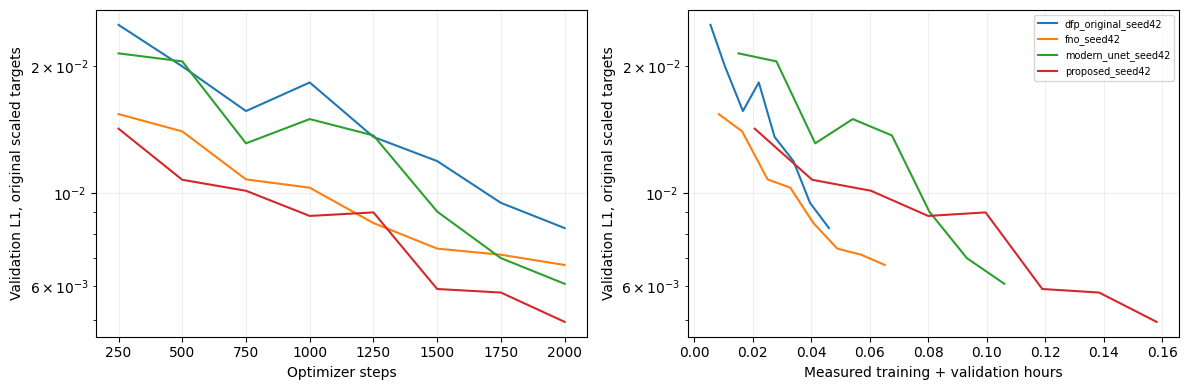

No full benchmark result exists. Validation or smoke values are not evidence of test superiority.


In [ ]:
validation_table = validation_run_table(STUDY_ROOT)
if not validation_table.empty:
    display(validation_table)
    plot_learning_histories(STUDY_ROOT)
else:
    print('No completed runs in this study.')
comparison_path = STUDY_ROOT/'primary_comparison.json'
if comparison_path.exists():
    display(read_json(comparison_path))
else:
    print('No full benchmark result exists. Validation or smoke values are not evidence of test superiority.')

## Mechanism, data-efficiency and distribution-shift studies

These are executable validation-only studies. Enable them before freezing the final benchmark. Each uses the same fixed seed set and full training budget. They are off by default because they add substantial training time.

| Study | Question |
|---|---|
| No alignment | Do flow and surface directions help beyond fixed Cartesian offsets? |
| Uniform stencil | Do learned neighbor weights help beyond valid uniform averaging? |
| No local refinement | Does the proposed mechanism improve the multiscale spectral backbone? |
| No SDF features | Do distance and normal features help while preserving raw geometry and freestream inputs? |
| No FiLM | Does conditional modulation help when scalar input channels are still available? |
| No spectral layers | Does nonlocal spectral processing help beyond local convolution? |
| Regional supervision | Does directly weighting target errors near the body/wake help? |
| Gradient supervision | Does matching sampled target gradients help? |
| Divergence matching | Does matching sampled reference divergence help? |
| Nested training subsets | Is the mechanism more data efficient at the same optimizer budget? |
| Geometry, speed, angle holdouts | Does the gain persist on deliberately shifted validation partitions? |

The additional partitions are development holdouts carved from the original training pool, not new independent official test sets. Choose loss weights and architecture settings on validation only. Equal-step results should be considered together with wall-clock cost and capacity.

**Purpose of the code.** Run the optional studies without using official test predictions for model development.

In [ ]:
if any([RUN_ABLATIONS, RUN_LEARNING_CURVES, RUN_GENERALIZATION]):
    if SMOKE or PROFILE == 'benchmark':
        raise ValueError('Run development studies on real data before entering the final benchmark profile.')
    run_development_studies(PREPARED_ROOT, PROJECT_ROOT/'runs'/STUDY_NAME/'development', split,
        ablations=RUN_ABLATIONS, learning_curves=RUN_LEARNING_CURVES,
        generalization=RUN_GENERALIZATION)
else:
    print('Optional development studies are disabled. Enable the corresponding flags above when ready.')

Optional development studies are disabled. Enable the corresponding flags above when ready.


## Matched qualitative test figures

After a completed frozen benchmark, compare the same deterministic test cases and seed with shared field and error scales. The first sample ID for each of the first three alphabetically sorted airfoils is used, so cases are not selected for favorable errors. Report worst cases and regional metrics too. No lift, drag, wall shear, or exact wall-pressure coefficient is inferred from this cropped raster archive.

**Purpose of the code.** Produce matched field and error maps after official test evaluation has completed.

In [ ]:
if PROFILE == 'benchmark' and (STUDY_ROOT/'primary_comparison.json').exists():
    test_manifest = pd.read_csv(PREPARED_ROOT/'manifest.csv')
    test_manifest = test_manifest[test_manifest.split == 'test'].sort_values(['airfoil_id','sample_id'])
    fixed_ids = test_manifest.groupby('airfoil_id', sort=True).first().head(3).sample_id.tolist()
    plot_seed = (SEEDS or [42,137,2026])[0]
    plot_matched_predictions(PREPARED_ROOT,
        {'DFP original': STUDY_ROOT/f'dfp_original_seed{plot_seed}',
         'Proposed': STUDY_ROOT/f'proposed_seed{plot_seed}'},
        fixed_ids, STUDY_ROOT/'figures')
else:
    print('Matched official-test figures become available after a completed benchmark.')

Matched official-test figures become available after a completed benchmark.




---



---



# **Ablation Test**

Run the ablation test without running the whole code


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Project: /content/drive/MyDrive/Colab Notebooks/Deep-Flow-Prediction/rans_airfoil_project/publication_v2
GPU: Tesla T4

Running: proposed
proposed_seed42: step 250/2000, val L1=0.014355
proposed_seed42: step 500/2000, val L1=0.010990
proposed_seed42: step 750/2000, val L1=0.009657
proposed_seed42: step 1000/2000, val L1=0.009650
proposed_seed42: step 1250/2000, val L1=0.009618
proposed_seed42: step 1500/2000, val L1=0.005854
proposed_seed42: step 1750/2000, val L1=0.005784
proposed_seed42: step 2000/2000, val L1=0.004938

Running: no_local_refinement
no_local_refinement_seed42: step 250/2000, val L1=0.015327
no_local_refinement_seed42: step 500/2000, val L1=0.010826
no_local_refinement_seed42: step 750/2000, val L1=0.009988
no_local_refinement_seed42: step 1000/2000, val L1=0.008847
no_local_refinement_seed42: step 1250/2000, val L1=0.009707
no_local_refineme

,experiment,steps,parameters,validation_L1,validation_relative_L1,validation_pressure_L2,validation_velocity_L2
0,no_alignment_seed42,2000,5690558,0.004949,0.024965,0.172579,0.039208
1,no_local_refinement_seed42,2000,5654707,0.005221,0.026390,0.188465,0.044993
2,proposed_seed42,2000,5690558,0.004938,0.024907,0.169089,0.039656
3,uniform_stencil_seed42,2000,5689142,0.004959,0.025016,0.169593,0.039808


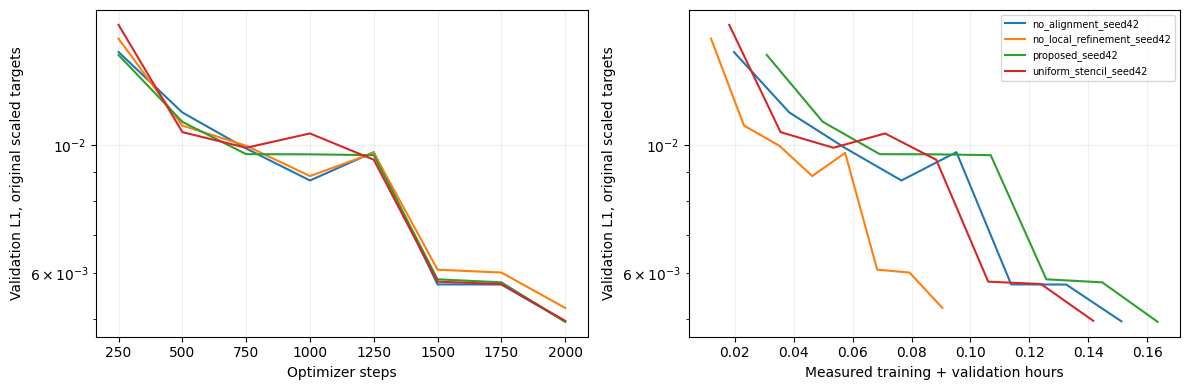

In [ ]:
# Reconnect and run ONLY the short ablation screen.
import copy
import importlib.util
import sys
from pathlib import Path

from google.colab import drive, files
from IPython.display import display

# 1. Reconnect Google Drive.
drive.mount("/content/drive")

PROJECT_ROOT = Path(
    "/content/drive/MyDrive/Colab Notebooks/Deep-Flow-Prediction/"
    "rans_airfoil_project/publication_v2"
)
PREPARED_ROOT = PROJECT_ROOT / "prepared"
SPLIT_PATH = PREPARED_ROOT / "splits" / "official_random_31415.json"
CORE_PATH = PROJECT_ROOT / "airfoil_publication_core.py"

# Require the existing preparation outputs.
for required in [PREPARED_ROOT / "metadata.json", SPLIT_PATH]:
    if not required.is_file():
        raise FileNotFoundError(
            f"Missing: {required}\n"
            "Check PROJECT_ROOT against the folder used for your completed training."
        )

# 2. Restore the implementation. Upload the helper only the first time.
if not CORE_PATH.is_file():
    print("Upload the downloaded airfoil_publication_core.py file.")
    uploaded = files.upload()
    filename = "airfoil_publication_core.py"
    if filename not in uploaded:
        raise FileNotFoundError(f"Please upload the file named {filename}.")
    CORE_PATH.write_bytes(uploaded[filename])

spec = importlib.util.spec_from_file_location(
    "airfoil_publication_core", CORE_PATH
)
core = importlib.util.module_from_spec(spec)
sys.modules[spec.name] = core
spec.loader.exec_module(core)

if not core.torch.cuda.is_available():
    raise RuntimeError(
        "Select Runtime → Change runtime type → GPU, then rerun this cell."
    )

# 3. Load the saved dataset metadata and original split.
metadata = core.verify_prepared_dataset(PREPARED_ROOT)
split = core.read_json(SPLIT_PATH)

if metadata["dataset_id"] != split["dataset_id"]:
    raise ValueError("The saved split belongs to a different prepared dataset.")
if metadata["settings"]["synthetic"]:
    raise ValueError("This screen requires your real CFD dataset.")

print("Project:", PROJECT_ROOT)
print("GPU:", core.torch.cuda.get_device_name(0))

# 4. Run only these four experiments, with the original short-screen budget.
ablation_root = PROJECT_ROOT / "runs" / "study_02" / "ablation_screen"
ablation_configs = core.experiment_configs("ablations")

names = [
    "proposed",
    "no_local_refinement",
    "no_alignment",
    "uniform_stencil",
]

for name in names:
    config = copy.deepcopy(ablation_configs[name])
    config.update(
        profile="screen",
        max_steps=2000,
        validation_every=250,
    )

    print(f"\nRunning: {name}")
    core.run_experiment(
        PREPARED_ROOT,
        ablation_root / f"{name}_seed42",
        split,
        config,
        seed=42,
        resume=True,
    )

# 5. Display the ablation results.
display(core.validation_run_table(ablation_root))
core.plot_learning_histories(ablation_root)

In [ ]:
# # Longer ablation study: 4 configurations × 3 seeds × 10,000 steps.
# # Uses existing prepared data. Does not evaluate the test set.

# import copy
# import importlib.util
# import sys
# from pathlib import Path

# from google.colab import drive
# from IPython.display import display

# # 1. Reconnect and restore the implementation.
# drive.mount("/content/drive")

# PROJECT_ROOT = Path(
#     "/content/drive/MyDrive/Colab Notebooks/Deep-Flow-Prediction/"
#     "rans_airfoil_project/publication_v2"
# )
# PREPARED_ROOT = PROJECT_ROOT / "prepared"
# CORE_PATH = PROJECT_ROOT / "airfoil_publication_core.py"
# SPLIT_PATH = PREPARED_ROOT / "splits" / "official_random_31415.json"

# for path in [CORE_PATH, SPLIT_PATH, PREPARED_ROOT / "metadata.json"]:
#     if not path.is_file():
#         raise FileNotFoundError(f"Required file missing: {path}")

# spec = importlib.util.spec_from_file_location(
#     "airfoil_publication_core", CORE_PATH
# )
# core = importlib.util.module_from_spec(spec)
# sys.modules[spec.name] = core
# spec.loader.exec_module(core)

# if not core.torch.cuda.is_available():
#     raise RuntimeError("Enable a GPU runtime, then rerun this cell.")

# metadata = core.verify_prepared_dataset(PREPARED_ROOT)
# split = core.read_json(SPLIT_PATH)

# if metadata["dataset_id"] != split["dataset_id"]:
#     raise ValueError("Dataset and saved split do not match.")
# if metadata["settings"]["synthetic"]:
#     raise ValueError("Real CFD data are required.")

# # 2. Fixed study configuration. Keep these settings unchanged on resume.
# SEEDS = [42, 123, 2026]
# MAX_STEPS = 10_000
# VALIDATION_EVERY = 500

# NAMES = [
#     "proposed",
#     "no_local_refinement",
#     "no_alignment",
#     "uniform_stencil",
# ]

# STUDY_ROOT = (
#     PROJECT_ROOT / "runs" / "study_03" / "ablations_10k_3seeds"
# )
# STUDY_ROOT.mkdir(parents=True, exist_ok=True)

# configs = core.experiment_configs("ablations")

# print("GPU:", core.torch.cuda.get_device_name(0))
# print("Results:", STUDY_ROOT)
# print(f"Study: {len(NAMES) * len(SEEDS)} runs, {MAX_STEPS:,} steps each")


# # 3. Save individual results and mean/std across completed seeds.
# def save_summary():
#     results = core.validation_run_table(STUDY_ROOT)
#     if results.empty:
#         return

#     results["variant"] = results["experiment"].str.replace(
#         r"_seed\d+$", "", regex=True
#     )
#     results["seed"] = (
#         results["experiment"].str.extract(r"_seed(\d+)$")[0].astype(int)
#     )

#     metrics = [
#         "validation_L1",
#         "validation_relative_L1",
#         "validation_pressure_L2",
#         "validation_velocity_L2",
#     ]

#     summary = results.groupby("variant")[metrics].agg(["mean", "std"])
#     summary.columns = [
#         f"{metric}_{stat}" for metric, stat in summary.columns
#     ]
#     summary.insert(
#         0, "completed_seeds",
#         results.groupby("variant")["seed"].nunique()
#     )
#     summary = summary.sort_values("validation_L1_mean")

#     results.to_csv(STUDY_ROOT / "completed_runs.csv", index=False)
#     summary.to_csv(STUDY_ROOT / "summary_mean_std.csv")

#     display(summary.round(6))


# # 4. Train each configuration with each seed.
# # Completed compatible runs reload their results without more optimizer steps.
# total_runs = len(SEEDS) * len(NAMES)
# run_number = 0

# for seed in SEEDS:
#     for name in NAMES:
#         run_number += 1
#         config = copy.deepcopy(configs[name])
#         config.update(
#             profile="ablations",
#             max_steps=MAX_STEPS,
#             validation_every=VALIDATION_EVERY,
#         )

#         print(
#             f"\n[{run_number}/{total_runs}] "
#             f"{name}, seed={seed}",
#             flush=True,
#         )

#         core.run_experiment(
#             PREPARED_ROOT,
#             STUDY_ROOT / f"{name}_seed{seed}",
#             split,
#             config,
#             seed=seed,
#             resume=True,
#         )

#         # Preserve the current summary after every completed run.
#         save_summary()

# print("\nAll 12 runs completed.")
# core.plot_learning_histories(STUDY_ROOT)

# print("\nShare these two files for the next analysis:")
# print(STUDY_ROOT / "completed_runs.csv")
# print(STUDY_ROOT / "summary_mean_std.csv")

Mounted at /content/drive
GPU: Tesla T4
Results: /content/drive/MyDrive/Colab Notebooks/Deep-Flow-Prediction/rans_airfoil_project/publication_v2/runs/study_03/ablations_10k_3seeds
Study: 12 runs, 10,000 steps each

[1/12] proposed, seed=42


,completed_seeds,validation_L1_mean,validation_L1_std,validation_relative_L1_mean,validation_relative_L1_std,validation_pressure_L2_mean,validation_pressure_L2_std,validation_velocity_L2_mean,validation_velocity_L2_std
variant,,,,,,,,,
proposed,1,0.003599,NaN,0.018049,NaN,0.113947,NaN,0.029578,NaN



[2/12] no_local_refinement, seed=42
no_local_refinement_seed42: step 4500/10000, val L1=0.006562
no_local_refinement_seed42: step 5000/10000, val L1=0.005273
no_local_refinement_seed42: step 5500/10000, val L1=0.005438
no_local_refinement_seed42: step 6000/10000, val L1=0.004664
no_local_refinement_seed42: step 6500/10000, val L1=0.004985
no_local_refinement_seed42: step 7000/10000, val L1=0.004764
no_local_refinement_seed42: step 7500/10000, val L1=0.004193
no_local_refinement_seed42: step 8000/10000, val L1=0.004215
no_local_refinement_seed42: step 8500/10000, val L1=0.003930
no_local_refinement_seed42: step 9000/10000, val L1=0.003854
no_local_refinement_seed42: step 9500/10000, val L1=0.003791
no_local_refinement_seed42: step 10000/10000, val L1=0.003646


,completed_seeds,validation_L1_mean,validation_L1_std,validation_relative_L1_mean,validation_relative_L1_std,validation_pressure_L2_mean,validation_pressure_L2_std,validation_velocity_L2_mean,validation_velocity_L2_std
variant,,,,,,,,,
proposed,1,0.003599,NaN,0.018049,NaN,0.113947,NaN,0.029578,NaN
no_local_refinement,1,0.003646,NaN,0.018314,NaN,0.121566,NaN,0.031109,NaN



[3/12] no_alignment, seed=42
no_alignment_seed42: step 500/10000, val L1=0.010534
no_alignment_seed42: step 1000/10000, val L1=0.009231
no_alignment_seed42: step 1500/10000, val L1=0.007193
no_alignment_seed42: step 2000/10000, val L1=0.006682
no_alignment_seed42: step 2500/10000, val L1=0.006897


# **==> If the runtime is disconnected. Run the following cell to continue from the last checkpoint**

In [ ]:
# ============================================================
# COLAB SAFE ABLATION RUNNER
# Runs only ONE unfinished experiment per execution.
# Rerun this cell after each completed experiment or disconnect.
# ============================================================

import copy
import importlib.util
import sys
from pathlib import Path

from google.colab import drive
from IPython.display import display

# ------------------------------------------------------------
# 1. Connect Google Drive
# ------------------------------------------------------------

drive.mount("/content/drive", force_remount=False)

PROJECT_ROOT = Path(
    "/content/drive/MyDrive/Colab Notebooks/Deep-Flow-Prediction/"
    "rans_airfoil_project/publication_v2"
)

PREPARED_ROOT = PROJECT_ROOT / "prepared"
CORE_PATH = PROJECT_ROOT / "airfoil_publication_core.py"
SPLIT_PATH = (
    PREPARED_ROOT
    / "splits"
    / "official_random_31415.json"
)

STUDY_ROOT = (
    PROJECT_ROOT
    / "runs"
    / "study_03"
    / "ablations_10k_3seeds"
)

required_files = [
    CORE_PATH,
    SPLIT_PATH,
    PREPARED_ROOT / "metadata.json",
]

for path in required_files:
    if not path.is_file():
        raise FileNotFoundError(f"Required file missing: {path}")


# ------------------------------------------------------------
# 2. Load the implementation
# ------------------------------------------------------------

module_name = "airfoil_publication_core"

if module_name in sys.modules:
    del sys.modules[module_name]

spec = importlib.util.spec_from_file_location(
    module_name,
    CORE_PATH,
)

core = importlib.util.module_from_spec(spec)
sys.modules[module_name] = core
spec.loader.exec_module(core)

if not core.torch.cuda.is_available():
    raise RuntimeError(
        "A GPU is unavailable. Select Runtime, Change runtime type, GPU."
    )

metadata = core.verify_prepared_dataset(PREPARED_ROOT)
split = core.read_json(SPLIT_PATH)

if metadata["dataset_id"] != split["dataset_id"]:
    raise ValueError("The prepared dataset and split do not match.")

if metadata["settings"]["synthetic"]:
    raise ValueError("The publication study requires real CFD data.")

STUDY_ROOT.mkdir(parents=True, exist_ok=True)

print("GPU:", core.torch.cuda.get_device_name(0))
print("Study folder:", STUDY_ROOT)


# ------------------------------------------------------------
# 3. Preserve the original experiment configuration
# ------------------------------------------------------------

SEEDS = [42, 123, 2026]

NAMES = [
    "proposed",
    "no_local_refinement",
    "no_alignment",
    "uniform_stencil",
]

MAX_STEPS = 10_000
VALIDATION_EVERY = 500

base_configs = core.experiment_configs("ablations")


def build_config(name):
    """Return the exact configuration used by the original 10k study."""

    config = copy.deepcopy(base_configs[name])

    config.update(
        profile="ablations",
        max_steps=MAX_STEPS,
        validation_every=VALIDATION_EVERY,
    )

    return config


# ------------------------------------------------------------
# 4. Inspect current progress
# ------------------------------------------------------------

def last_saved_step(run_directory):
    """Read progress without loading the large PyTorch checkpoint."""

    completion_path = run_directory / "training_complete.json"

    if completion_path.is_file():
        completion = core.read_json(completion_path)
        return int(completion["completed_steps"]), "completed"

    history_path = run_directory / "history.csv"

    if history_path.is_file():
        history = core.pd.read_csv(history_path)

        if not history.empty:
            return int(history["step"].max()), "partial"

    return 0, "waiting"


run_order = [
    (seed, name)
    for seed in SEEDS
    for name in NAMES
]

status_rows = []
unfinished_runs = []

for seed, name in run_order:
    run_name = f"{name}_seed{seed}"
    run_directory = STUDY_ROOT / run_name

    saved_step, status = last_saved_step(run_directory)

    status_rows.append(
        {
            "experiment": run_name,
            "saved_step": saved_step,
            "target_steps": MAX_STEPS,
            "progress_percent": 100 * saved_step / MAX_STEPS,
            "status": status,
        }
    )

    if status != "completed":
        unfinished_runs.append((seed, name, run_directory))

status_table = core.pd.DataFrame(status_rows)

print("\nCurrent study progress:")
display(status_table)


# ------------------------------------------------------------
# 5. Run only the first unfinished experiment
# ------------------------------------------------------------

if not unfinished_runs:
    print("\nAll 12 experiments are already complete.")

else:
    seed, name, run_directory = unfinished_runs[0]

    previous_step, previous_status = last_saved_step(run_directory)

    print("\nExperiment selected for this session")
    print("Model:", name)
    print("Seed:", seed)
    print("Starting from saved step:", previous_step)
    print("Target:", MAX_STEPS)

    config = build_config(name)

    core.run_experiment(
        prepared_root=PREPARED_ROOT,
        run_root=run_directory,
        split=split,
        config=config,
        seed=seed,
        resume=True,
    )

    print(f"\nCompleted: {name}, seed={seed}")


# ------------------------------------------------------------
# 6. Save a summary of all completed experiments
# ------------------------------------------------------------

results = core.validation_run_table(STUDY_ROOT)

if not results.empty:

    results["variant"] = results["experiment"].str.replace(
        r"_seed\d+$",
        "",
        regex=True,
    )

    results["seed"] = (
        results["experiment"]
        .str.extract(r"_seed(\d+)$")[0]
        .astype(int)
    )

    metric_columns = [
        "validation_L1",
        "validation_relative_L1",
        "validation_pressure_L2",
        "validation_velocity_L2",
    ]

    summary = results.groupby("variant")[metric_columns].agg(
        ["mean", "std"]
    )

    summary.columns = [
        f"{metric}_{statistic}"
        for metric, statistic in summary.columns
    ]

    completed_seed_counts = (
        results.groupby("variant")["seed"].nunique()
    )

    summary.insert(
        0,
        "completed_seeds",
        completed_seed_counts,
    )

    summary = summary.sort_values(
        "validation_L1_mean"
    )

    results.to_csv(
        STUDY_ROOT / "completed_runs.csv",
        index=False,
    )

    summary.to_csv(
        STUDY_ROOT / "summary_mean_std.csv"
    )

    print("\nResults from completed experiments:")
    display(results.sort_values(["seed", "variant"]))

    print("\nCurrent mean and standard deviation:")
    display(summary.round(6))


# ------------------------------------------------------------
# 7. Show what remains
# ------------------------------------------------------------

remaining = []

for seed, name in run_order:
    run_directory = STUDY_ROOT / f"{name}_seed{seed}"
    saved_step, status = last_saved_step(run_directory)

    if status != "completed":
        remaining.append(
            {
                "experiment": f"{name}_seed{seed}",
                "saved_step": saved_step,
                "remaining_steps": MAX_STEPS - saved_step,
            }
        )

if remaining:
    print("\nRun this same cell again for the next experiment:")
    display(core.pd.DataFrame(remaining))

else:
    print("\nAll 12 experiments completed successfully.")
    print("Completed results:", STUDY_ROOT / "completed_runs.csv")
    print("Summary:", STUDY_ROOT / "summary_mean_std.csv")

    core.plot_learning_histories(STUDY_ROOT)

Mounted at /content/drive
GPU: Tesla T4
Study folder: /content/drive/MyDrive/Colab Notebooks/Deep-Flow-Prediction/rans_airfoil_project/publication_v2/runs/study_03/ablations_10k_3seeds

Current study progress:


,experiment,saved_step,target_steps,progress_percent,status
0,proposed_seed42,10000,10000,100.0,completed
1,no_local_refinement_seed42,10000,10000,100.0,completed
2,no_alignment_seed42,10000,10000,100.0,completed
3,uniform_stencil_seed42,2500,10000,25.0,partial
4,proposed_seed123,0,10000,0.0,waiting
5,no_local_refinement_seed123,0,10000,0.0,waiting
6,no_alignment_seed123,0,10000,0.0,waiting
7,uniform_stencil_seed123,0,10000,0.0,waiting
8,proposed_seed2026,0,10000,0.0,waiting
9,no_local_refinement_seed2026,0,10000,0.0,waiting



Experiment selected for this session
Model: uniform_stencil
Seed: 42
Starting from saved step: 2500
Target: 10000
uniform_stencil_seed42: step 3000/10000, val L1=0.006459
uniform_stencil_seed42: step 3500/10000, val L1=0.005684
uniform_stencil_seed42: step 4000/10000, val L1=0.005905
uniform_stencil_seed42: step 4500/10000, val L1=0.006766
uniform_stencil_seed42: step 5000/10000, val L1=0.005266



# Run the following cell again four times. It will progress automatically:

+ 6,000 to 7,000
+ 7,000 to 8,000
+ 8,000 to 9,000
+ 9,000 to 10,000

After that, it will automatically start **proposed_seed123**.

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
GPU: Tesla T4
Study folder: /content/drive/MyDrive/Colab Notebooks/Deep-Flow-Prediction/rans_airfoil_project/publication_v2/runs/study_03/ablations_10k_3seeds

Current progress:


,experiment,saved_step,target,remaining,progress_percent,status
0,proposed_seed42,10000,10000,0,100.0,completed
1,no_local_refinement_seed42,10000,10000,0,100.0,completed
2,no_alignment_seed42,10000,10000,0,100.0,completed
3,uniform_stencil_seed42,10000,10000,0,100.0,completed
4,proposed_seed123,10000,10000,0,100.0,completed
5,no_local_refinement_seed123,10000,10000,0,100.0,completed
6,no_alignment_seed123,10000,10000,0,100.0,completed
7,uniform_stencil_seed123,10000,10000,0,100.0,completed
8,proposed_seed2026,10000,10000,0,100.0,completed
9,no_local_refinement_seed2026,10000,10000,0,100.0,completed



All 12 experiments are complete.

Completed experiments:


,experiment,steps,parameters,validation_L1,validation_relative_L1,validation_pressure_L2,validation_velocity_L2,variant,seed
2,no_alignment_seed42,10000,5690558,0.003579,0.017953,0.112037,0.029077,no_alignment,42
5,no_local_refinement_seed42,10000,5654707,0.003646,0.018314,0.121566,0.031109,no_local_refinement,42
8,proposed_seed42,10000,5690558,0.003599,0.018049,0.113947,0.029578,proposed,42
11,uniform_stencil_seed42,10000,5689142,0.003598,0.018049,0.113660,0.029324,uniform_stencil,42
0,no_alignment_seed123,10000,5690558,0.003733,0.018684,0.113460,0.029638,no_alignment,123
3,no_local_refinement_seed123,10000,5654707,0.003834,0.019219,0.125401,0.033117,no_local_refinement,123
6,proposed_seed123,10000,5690558,0.003737,0.018711,0.114119,0.029654,proposed,123
9,uniform_stencil_seed123,10000,5689142,0.003740,0.018726,0.115232,0.029960,uniform_stencil,123
1,no_alignment_seed2026,10000,5690558,0.003654,0.018299,0.111585,0.029113,no_alignment,2026
4,no_local_refinement_seed2026,10000,5654707,0.003714,0.018615,0.122796,0.031898,no_local_refinement,2026



Current summary:


,completed_seeds,validation_L1_mean,validation_L1_std,validation_relative_L1_mean,validation_relative_L1_std,validation_pressure_L2_mean,validation_pressure_L2_std,validation_velocity_L2_mean,validation_velocity_L2_std
variant,,,,,,,,,
no_alignment,3,0.003655,0.000077,0.018312,0.000366,0.112361,0.000978,0.029276,0.000314
proposed,3,0.003661,0.000070,0.018334,0.000341,0.113038,0.001725,0.029434,0.000318
uniform_stencil,3,0.003666,0.000071,0.018366,0.000341,0.112802,0.002954,0.029474,0.000432
no_local_refinement,3,0.003731,0.000095,0.018716,0.000461,0.123254,0.001958,0.032041,0.001011



All experiments completed successfully.
/content/drive/MyDrive/Colab Notebooks/Deep-Flow-Prediction/rans_airfoil_project/publication_v2/runs/study_03/ablations_10k_3seeds/completed_runs.csv
/content/drive/MyDrive/Colab Notebooks/Deep-Flow-Prediction/rans_airfoil_project/publication_v2/runs/study_03/ablations_10k_3seeds/summary_mean_std.csv


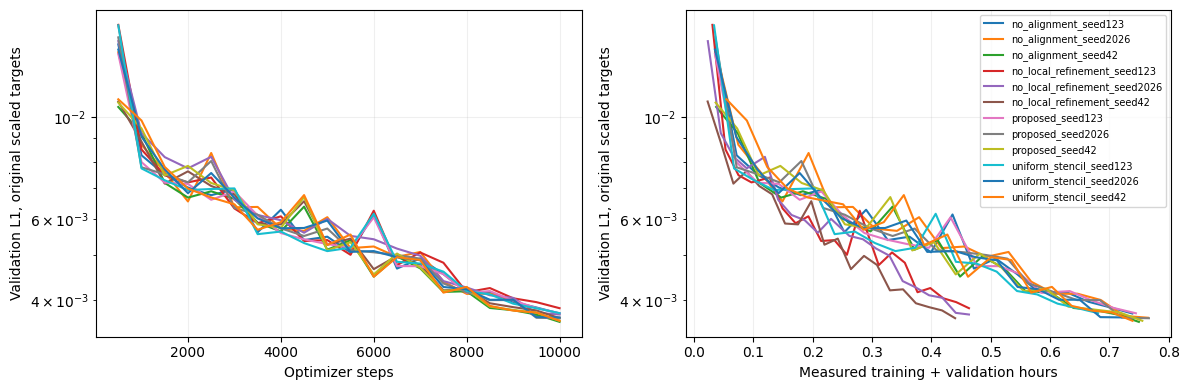

In [3]:
# ============================================================
# COLAB LIMITED RUNTIME RUNNER
# Advances one experiment by only 1,000 steps per execution.
# ============================================================

import copy
import gc
import importlib.util
import sys
from pathlib import Path

from google.colab import drive
from IPython.display import display


# ------------------------------------------------------------
# 1. Connect Drive
# ------------------------------------------------------------

drive.mount("/content/drive", force_remount=False)

PROJECT_ROOT = Path(
    "/content/drive/MyDrive/Colab Notebooks/Deep-Flow-Prediction/"
    "rans_airfoil_project/publication_v2"
)

PREPARED_ROOT = PROJECT_ROOT / "prepared"

STUDY_ROOT = (
    PROJECT_ROOT
    / "runs"
    / "study_03"
    / "ablations_10k_3seeds"
)

CORE_PATH = PROJECT_ROOT / "airfoil_publication_core.py"

SPLIT_PATH = (
    PREPARED_ROOT
    / "splits"
    / "official_random_31415.json"
)

for required_path in [
    CORE_PATH,
    SPLIT_PATH,
    PREPARED_ROOT / "metadata.json",
]:
    if not required_path.is_file():
        raise FileNotFoundError(
            f"Required file is missing: {required_path}"
        )


# ------------------------------------------------------------
# 2. Load the original implementation
# ------------------------------------------------------------

module_name = "airfoil_publication_core"

if module_name in sys.modules:
    del sys.modules[module_name]

spec = importlib.util.spec_from_file_location(
    module_name,
    CORE_PATH,
)

core = importlib.util.module_from_spec(spec)
sys.modules[module_name] = core
spec.loader.exec_module(core)

if not core.torch.cuda.is_available():
    raise RuntimeError(
        "GPU unavailable. Select Runtime > Change runtime type > GPU."
    )

metadata = core.verify_prepared_dataset(PREPARED_ROOT)
split = core.read_json(SPLIT_PATH)

if metadata["dataset_id"] != split["dataset_id"]:
    raise ValueError("The dataset and saved split do not match.")

if metadata["settings"]["synthetic"]:
    raise ValueError("The real CFD dataset is required.")

STUDY_ROOT.mkdir(parents=True, exist_ok=True)

print("GPU:", core.torch.cuda.get_device_name(0))
print("Study folder:", STUDY_ROOT)


# ------------------------------------------------------------
# 3. Original study settings
# ------------------------------------------------------------

SEEDS = [42, 123, 2026]

VARIANTS = [
    "proposed",
    "no_local_refinement",
    "no_alignment",
    "uniform_stencil",
]

MAX_STEPS = 10_000
VALIDATION_EVERY = 500

# Only this number controls the duration of the current session.
CHUNK_STEPS = 3_000

base_configs = core.experiment_configs("ablations")


def make_config(variant):
    config = copy.deepcopy(base_configs[variant])

    config.update(
        profile="ablations",
        max_steps=MAX_STEPS,
        validation_every=VALIDATION_EVERY,
    )

    return config


# ------------------------------------------------------------
# 4. Inspect saved progress
# ------------------------------------------------------------

def get_saved_step(run_directory):
    history_path = run_directory / "history.csv"

    if not history_path.is_file():
        return 0

    history = core.pd.read_csv(history_path)

    if history.empty or "step" not in history.columns:
        return 0

    return int(history["step"].max())


def is_completed(run_directory):
    saved_step = get_saved_step(run_directory)
    completion_path = run_directory / "training_complete.json"

    return (
        saved_step >= MAX_STEPS
        and completion_path.is_file()
    )


run_order = [
    (seed, variant)
    for seed in SEEDS
    for variant in VARIANTS
]


# Remove any incorrect completion marker left by an interrupted
# earlier chunk execution.
for seed, variant in run_order:
    run_directory = STUDY_ROOT / f"{variant}_seed{seed}"
    completion_path = run_directory / "training_complete.json"
    saved_step = get_saved_step(run_directory)

    if completion_path.is_file() and saved_step < MAX_STEPS:
        completion_path.unlink()


progress_rows = []
unfinished = []

for seed, variant in run_order:
    run_directory = STUDY_ROOT / f"{variant}_seed{seed}"
    saved_step = get_saved_step(run_directory)
    complete = is_completed(run_directory)

    if complete:
        status = "completed"
    elif saved_step > 0:
        status = "partial"
    else:
        status = "waiting"

    progress_rows.append(
        {
            "experiment": f"{variant}_seed{seed}",
            "saved_step": saved_step,
            "target": MAX_STEPS,
            "remaining": MAX_STEPS - saved_step,
            "progress_percent": round(
                100 * saved_step / MAX_STEPS,
                1,
            ),
            "status": status,
        }
    )

    if not complete:
        unfinished.append(
            {
                "seed": seed,
                "variant": variant,
                "run_directory": run_directory,
                "saved_step": saved_step,
            }
        )

print("\nCurrent progress:")
display(core.pd.DataFrame(progress_rows))


# ------------------------------------------------------------
# 5. Select one unfinished experiment
# ------------------------------------------------------------

if not unfinished:

    print("\nAll 12 experiments are complete.")

else:

    selected = unfinished[0]

    seed = selected["seed"]
    variant = selected["variant"]
    run_directory = selected["run_directory"]
    starting_step = selected["saved_step"]

    expected_end = min(
        starting_step + CHUNK_STEPS,
        MAX_STEPS,
    )

    print("\nSelected experiment:", f"{variant}_seed{seed}")
    print("Starting checkpoint:", starting_step)
    print("This execution stops at:", expected_end)
    print("Final experiment target:", MAX_STEPS)

    config = make_config(variant)


    # --------------------------------------------------------
    # 6. Temporarily limit the sampler to this short chunk
    # --------------------------------------------------------

    OriginalSampler = core.StepBatchSampler
    OriginalFingerprint = core.implementation_fingerprint
    OriginalWriteJson = core.write_json

    original_code_hash = core.CODE_SHA256

    chunk_state = {
        "limited": False,
        "end_step": None,
    }


    class LimitedStepBatchSampler(OriginalSampler):

        def __init__(
            self,
            n,
            batch_size,
            start_step,
            end_step,
            sampler_seed,
        ):
            limited_end = min(
                end_step,
                start_step + CHUNK_STEPS,
            )

            chunk_state["limited"] = limited_end < end_step
            chunk_state["end_step"] = limited_end

            super().__init__(
                n=n,
                batch_size=batch_size,
                start_step=start_step,
                end_step=limited_end,
                seed=sampler_seed,
            )


    def preserve_original_fingerprint():
        # The model, loss, optimizer, data order and learning-rate
        # schedule remain identical to the original experiment.
        return original_code_hash


    def guarded_write_json(path, value):
        path = Path(path)

        # A partial chunk must not be labelled as a completed
        # 10,000-step experiment.
        if (
            path.name == "training_complete.json"
            and chunk_state["limited"]
        ):
            return None

        return OriginalWriteJson(path, value)


    core.StepBatchSampler = LimitedStepBatchSampler
    core.implementation_fingerprint = preserve_original_fingerprint
    core.write_json = guarded_write_json


    # --------------------------------------------------------
    # 7. Run the short chunk
    # --------------------------------------------------------

    try:

        core.run_experiment(
            prepared_root=PREPARED_ROOT,
            run_root=run_directory,
            split=split,
            config=config,
            seed=seed,
            resume=True,
        )

    finally:

        # Restore the original module functions.
        core.StepBatchSampler = OriginalSampler
        core.implementation_fingerprint = OriginalFingerprint
        core.write_json = OriginalWriteJson

        gc.collect()

        if core.torch.cuda.is_available():
            core.torch.cuda.empty_cache()


    # --------------------------------------------------------
    # 8. Verify the saved checkpoint
    # --------------------------------------------------------

    new_saved_step = get_saved_step(run_directory)
    completion_path = run_directory / "training_complete.json"

    if new_saved_step < MAX_STEPS:
        completion_path.unlink(missing_ok=True)

    if new_saved_step <= starting_step:
        raise RuntimeError(
            "The checkpoint did not advance. Inspect the output above."
        )

    print("\nChunk completed successfully.")
    print("Previous saved step:", starting_step)
    print("New saved step:", new_saved_step)
    print("Remaining steps:", MAX_STEPS - new_saved_step)


# ------------------------------------------------------------
# 9. Save and display completed-run results
# ------------------------------------------------------------

results = core.validation_run_table(STUDY_ROOT)

if not results.empty:

    results["variant"] = results["experiment"].str.replace(
        r"_seed\d+$",
        "",
        regex=True,
    )

    results["seed"] = (
        results["experiment"]
        .str.extract(r"_seed(\d+)$")[0]
        .astype(int)
    )

    metrics = [
        "validation_L1",
        "validation_relative_L1",
        "validation_pressure_L2",
        "validation_velocity_L2",
    ]

    summary = results.groupby("variant")[metrics].agg(
        ["mean", "std"]
    )

    summary.columns = [
        f"{metric}_{statistic}"
        for metric, statistic in summary.columns
    ]

    summary.insert(
        0,
        "completed_seeds",
        results.groupby("variant")["seed"].nunique(),
    )

    summary = summary.sort_values(
        "validation_L1_mean"
    )

    results.to_csv(
        STUDY_ROOT / "completed_runs.csv",
        index=False,
    )

    summary.to_csv(
        STUDY_ROOT / "summary_mean_std.csv",
    )

    print("\nCompleted experiments:")
    display(results.sort_values(["seed", "variant"]))

    print("\nCurrent summary:")
    display(summary.round(6))


# ------------------------------------------------------------
# 10. Display the next action
# ------------------------------------------------------------

remaining_rows = []

for seed, variant in run_order:
    run_directory = STUDY_ROOT / f"{variant}_seed{seed}"
    saved_step = get_saved_step(run_directory)

    if not is_completed(run_directory):
        remaining_rows.append(
            {
                "experiment": f"{variant}_seed{seed}",
                "saved_step": saved_step,
                "remaining_steps": MAX_STEPS - saved_step,
            }
        )

if remaining_rows:

    print("\nRun this same cell again to continue:")
    display(core.pd.DataFrame(remaining_rows))

else:

    print("\nAll experiments completed successfully.")
    print(STUDY_ROOT / "completed_runs.csv")
    print(STUDY_ROOT / "summary_mean_std.csv")

    core.plot_learning_histories(STUDY_ROOT)

## What the publication can claim after successful experiments

If the prespecified comparison passes, report the measured improvement, paired interval, training data size, seed count, exact comparison architecture, and compute cost. Demonstrate the mechanism with ablations and inspect pressure, near-surface and wake failures. A larger model winning alone is insufficient to attribute the gain to the proposed mechanism.

If the criterion fails, report that result and continue development using a fresh validation plan. Do not relabel smoke output, screening losses, best-case visualizations, or a selectively chosen test model as a superiority result. A claim about a new architectural contribution also needs direct differentiation from current operator and geometry-aware literature.

The full bundle includes an independently runnable CPU integration test, retained historical source files, environment and validation reports, and a change log. Original V1 files are preserved separately; their caches and trained weights should not be reused with this revision.

## Sources and limits of the contribution

* Thuerey et al., [Deep Learning Methods for Reynolds-Averaged Navier-Stokes Simulations of Airfoil Flows](https://arxiv.org/abs/1810.08217), provided version 3. The released experiment uses a cropped Cartesian sampling of RANS solutions, not the full solver mesh.
* [Historical network](https://github.com/thunil/Deep-Flow-Prediction/blob/8a5efa4/train/DfpNet.py), [normalization](https://github.com/thunil/Deep-Flow-Prediction/blob/8a5efa4/train/dataset.py), and [evaluation](https://github.com/thunil/Deep-Flow-Prediction/blob/8a5efa4/train/runTest.py). The embedded generator retains its original attribution. The surrounding workflow is revised; the unused discriminator is omitted.
* [Generator sampling coordinates](https://github.com/thunil/Deep-Flow-Prediction/blob/master/data/utils.py) and [repository viscosity](https://github.com/thunil/Deep-Flow-Prediction/blob/master/data/OpenFOAM/constant/transportProperties). The paper's Reynolds mapping and the visible repository viscosity are not sufficient to establish the exact viscosity used for every archived sample.
* [U-FNO](https://arxiv.org/abs/2109.03697), [Geo-FNO](https://arxiv.org/abs/2207.05209), [GINO](https://arxiv.org/abs/2309.00583), and [geometry-aware airfoil prediction using coordinate transformations](https://arxiv.org/abs/2109.02183) establish relevant prior work. Adding Fourier layers, an SDF, or a U-Net is not by itself a novelty claim.
* Related [SDF derivative constraints](https://arxiv.org/abs/2503.17289) and [DD-RNO](https://arxiv.org/abs/2608.13490) must also be considered when positioning geometry and regional processing. This release does not claim to be the first such method.

The research hypothesis is that adaptive local feature differences, sampled along flow and surface directions and iterated after a multiscale spectral prediction, improve airfoil prediction at a useful cost. The included ablations can test that hypothesis. Originality still requires a focused comparison with current work. Generalization beyond this fixed raster dataset, drag accuracy, and resolution-independent operator learning are not established here.